# Task 5 random-file explorer

This notebook loads one random Task 5 input parquet file from MINGO04.

Search order:

1. `UNPROCESSED_DIRECTORY`
2. `COMPLETED_DIRECTORY`

It provides quick schema inspection, histograms, scatter plots, hexbin plots,
configurable pairwise comparisons, `tt_task5_post` time-binned comparisons,
correlation matrices, and plane/strip quick-look plots.


In [1]:
from pathlib import Path
from itertools import combinations
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 250)

BASE = Path("/home/mingo/DATAFLOW_v3/STATIONS/MINGO04/STAGE_1/EVENT_DATA/STEP_1/TASK_5/INPUT_FILES")
UNPROCESSED_DIR = BASE / "UNPROCESSED_DIRECTORY"
COMPLETED_DIR = BASE / "COMPLETED_DIRECTORY"

RANDOM_SEED = None
MAX_ROWS_FOR_PLOTS = 100_000
MAX_ROWS_FOR_SCATTER = 50_000
HEXBIN_GRIDSIZE = 80

if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)


## 1. Select and load one random parquet file


In [2]:
def find_parquet_files(directory: Path) -> list[Path]:
    if not directory.exists():
        return []
    return sorted(directory.glob("*.parquet"))

unprocessed_files = find_parquet_files(UNPROCESSED_DIR)
completed_files = find_parquet_files(COMPLETED_DIR)

if unprocessed_files:
    selected_pool = "UNPROCESSED_DIRECTORY"
    selected_file = random.choice(unprocessed_files)
elif completed_files:
    selected_pool = "COMPLETED_DIRECTORY"
    selected_file = random.choice(completed_files)
else:
    raise FileNotFoundError(
        "No parquet files found in either:\\n"
        f"  {UNPROCESSED_DIR}\\n"
        f"  {COMPLETED_DIR}"
    )

print(f"Selected pool: {selected_pool}")
print(f"Selected file: {selected_file}")

df = pd.read_parquet(selected_file)

print(f"Loaded shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
display(df.head())


Selected pool: COMPLETED_DIRECTORY
Selected file: /home/mingo/DATAFLOW_v3/STATIONS/MINGO04/STAGE_1/EVENT_DATA/STEP_1/TASK_5/INPUT_FILES/COMPLETED_DIRECTORY/fitted_mi0426032065559.parquet
Loaded shape: 45,851 rows × 335 columns


,datetime,event_id,acquisition_type,p4_s1_ef_t,p4_s2_ef_t,p4_s3_ef_t,p4_s4_ef_t,p4_s1_eb_t,p4_s2_eb_t,p4_s3_eb_t,p4_s4_eb_t,p4_s1_ef_q,p4_s2_ef_q,p4_s3_ef_q,p4_s4_ef_q,p4_s1_eb_q,p4_s2_eb_q,p4_s3_eb_q,p4_s4_eb_q,p3_s1_ef_t,p3_s2_ef_t,p3_s3_ef_t,p3_s4_ef_t,p3_s1_eb_t,p3_s2_eb_t,p3_s3_eb_t,p3_s4_eb_t,p3_s1_ef_q,p3_s2_ef_q,p3_s3_ef_q,p3_s4_ef_q,p3_s1_eb_q,p3_s2_eb_q,p3_s3_eb_q,p3_s4_eb_q,p2_s1_ef_t,p2_s2_ef_t,p2_s3_ef_t,p2_s4_ef_t,p2_s1_eb_t,p2_s2_eb_t,p2_s3_eb_t,p2_s4_eb_t,p2_s1_ef_q,p2_s2_ef_q,p2_s3_ef_q,p2_s4_ef_q,p2_s1_eb_q,p2_s2_eb_q,p2_s3_eb_q,p2_s4_eb_q,p1_s1_ef_t,p1_s2_ef_t,p1_s3_ef_t,p1_s4_ef_t,p1_s1_eb_t,p1_s2_eb_t,p1_s3_eb_t,p1_s4_eb_t,p1_s1_ef_q,p1_s2_ef_q,p1_s3_ef_q,p1_s4_ef_q,p1_s1_eb_q,p1_s2_eb_q,p1_s3_eb_q,p1_s4_eb_q,param_hash,tt_task0_acq,topology_task1_channel,tt_task0_raw,transferred_task0_acq_to_raw,filter_task1_problematic_channel_count,filter_task1_problematic_channel_exact,tt_task1_clean,transferred_task1_raw_to_clean,p1_s1_tsum,p1_s1_tdif,p1_s1_qsum,p1_s1_qdif,p1_s2_tsum,p1_s2_tdif,p1_s2_qsum,p1_s2_qdif,p1_s3_tsum,p1_s3_tdif,p1_s3_qsum,p1_s3_qdif,p1_s4_tsum,p1_s4_tdif,p1_s4_qsum,p1_s4_qdif,p2_s1_tsum,p2_s1_tdif,p2_s1_qsum,p2_s1_qdif,p2_s2_tsum,p2_s2_tdif,p2_s2_qsum,p2_s2_qdif,p2_s3_tsum,p2_s3_tdif,p2_s3_qsum,p2_s3_qdif,p2_s4_tsum,p2_s4_tdif,p2_s4_qsum,p2_s4_qdif,p3_s1_tsum,p3_s1_tdif,p3_s1_qsum,p3_s1_qdif,p3_s2_tsum,p3_s2_tdif,p3_s2_qsum,p3_s2_qdif,p3_s3_tsum,p3_s3_tdif,p3_s3_qsum,p3_s3_qdif,p3_s4_tsum,p3_s4_tdif,p3_s4_qsum,p3_s4_qdif,p4_s1_tsum,...,event_det_ext_res_tdif_4,event_det_th_chi,event_det_tt_task3_list,event_det_t0,event_tim_x,event_tim_xp,event_tim_y,event_tim_yp,event_tim_t0,event_tim_s,event_tim_th_chi,event_tim_res_y,event_tim_res_ts,event_tim_res_td,event_tim_tt_task3_list,event_tim_res_ystr_1,event_tim_res_ystr_2,event_tim_res_ystr_3,event_tim_res_ystr_4,event_tim_res_tsum_1,event_tim_res_tsum_2,event_tim_res_tsum_3,event_tim_res_tsum_4,event_tim_res_tdif_1,event_tim_res_tdif_2,event_tim_res_tdif_3,event_tim_res_tdif_4,event_tim_ext_res_ystr_1,event_tim_ext_res_ystr_2,event_tim_ext_res_ystr_3,event_tim_ext_res_ystr_4,event_tim_ext_res_tsum_1,event_tim_ext_res_tsum_2,event_tim_ext_res_tsum_3,event_tim_ext_res_tsum_4,event_tim_ext_res_tdif_1,event_tim_ext_res_tdif_2,event_tim_ext_res_tdif_3,event_tim_ext_res_tdif_4,event_tim_p1_qsum,event_tim_p2_qsum,event_tim_p3_qsum,event_tim_p4_qsum,event_tim_event_charge,event_tim_timtrack_iterations,event_tim_timtrack_conv_distance,event_tim_timtrack_converged,event_tim_charge_1,event_tim_charge_2,event_tim_charge_3,event_tim_charge_4,th_chisq_df_0,th_chisq_df_3,th_chisq_df_6,event_tim_theta,event_tim_phi,event_xp,event_yp,p1_ystr_res,p1_tsum_res,p1_tdif_res,p1_ystr_res_ext,p1_tsum_res_ext,p1_tdif_res_ext,p2_ystr_res,p2_tsum_res,p2_tdif_res,p2_ystr_res_ext,p2_tsum_res_ext,p2_tdif_res_ext,p3_ystr_res,p3_tsum_res,p3_tdif_res,p3_ystr_res_ext,p3_tsum_res_ext,p3_tdif_res_ext,p4_ystr_res,p4_tsum_res,p4_tdif_res,p4_ystr_res_ext,p4_tsum_res_ext,p4_tdif_res_ext,event_charge,timtrack_iterations,timtrack_conv_distance,timtrack_converged,event_x,event_x_err,event_y,event_y_err,event_theta,event_theta_err,event_phi,event_phi_err,event_s,event_t0,event_t0_err,p1_ystr_res_err,p2_ystr_res_err,p3_ystr_res_err,p4_ystr_res_err,p1_tsum_res_err,p2_tsum_res_err,p3_tsum_res_err,p4_tsum_res_err,p1_tdif_res_err,p2_tdif_res_err,p3_tdif_res_err,p4_tdif_res_err,p1_ystr_res_ext_err,p2_ystr_res_ext_err,p3_ystr_res_ext_err,p4_ystr_res_ext_err,p1_tsum_res_ext_err,p2_tsum_res_ext_err,p3_tsum_res_ext_err,p4_tsum_res_ext_err,p1_tdif_res_ext_err,p2_tdif_res_ext_err,p3_tdif_res_ext_err,p4_tdif_res_ext_err,event_s_err,tt_task4_fit,tt_task4_projected,event_tim_th_chi_sigmafit_1234
0,2026-02-01 06:55:59,1,1,-119.300003,0.000000,0.0,0.0,-123.099998,0.000000,0.0,0.0,97.339996,0.000000,0.0,0.0,99.690002,0.000000,0.0,0.0,0.0,0.000000,-121.900002,0.0,0.000000,0.000000,-123.300003,0.0,0.000000,0.000000,101.00,0.0,0.000000,0.000000,95.510002,0.0,0.000000,-125.300003,0.0,0.0,0.000000,-122.900002,0.

## 2. Schema and missing-value overview


In [3]:
print("Columns:")
for col in df.columns:
    print(col)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = [c for c in df.columns if c not in numeric_cols]

print(f"\\nNumeric columns: {len(numeric_cols)}")
print(f"Non-numeric columns: {len(non_numeric_cols)}")

missing = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .to_frame()
)
display(missing.head(80))

if numeric_cols:
    display(df[numeric_cols].describe().T)


Columns:
datetime
event_id
acquisition_type
p4_s1_ef_t
p4_s2_ef_t
p4_s3_ef_t
p4_s4_ef_t
p4_s1_eb_t
p4_s2_eb_t
p4_s3_eb_t
p4_s4_eb_t
p4_s1_ef_q
p4_s2_ef_q
p4_s3_ef_q
p4_s4_ef_q
p4_s1_eb_q
p4_s2_eb_q
p4_s3_eb_q
p4_s4_eb_q
p3_s1_ef_t
p3_s2_ef_t
p3_s3_ef_t
p3_s4_ef_t
p3_s1_eb_t
p3_s2_eb_t
p3_s3_eb_t
p3_s4_eb_t
p3_s1_ef_q
p3_s2_ef_q
p3_s3_ef_q
p3_s4_ef_q
p3_s1_eb_q
p3_s2_eb_q
p3_s3_eb_q
p3_s4_eb_q
p2_s1_ef_t
p2_s2_ef_t
p2_s3_ef_t
p2_s4_ef_t
p2_s1_eb_t
p2_s2_eb_t
p2_s3_eb_t
p2_s4_eb_t
p2_s1_ef_q
p2_s2_ef_q
p2_s3_ef_q
p2_s4_ef_q
p2_s1_eb_q
p2_s2_eb_q
p2_s3_eb_q
p2_s4_eb_q
p1_s1_ef_t
p1_s2_ef_t
p1_s3_ef_t
p1_s4_ef_t
p1_s1_eb_t
p1_s2_eb_t
p1_s3_eb_t
p1_s4_eb_t
p1_s1_ef_q
p1_s2_ef_q
p1_s3_ef_q
p1_s4_ef_q
p1_s1_eb_q
p1_s2_eb_q
p1_s3_eb_q
p1_s4_eb_q
param_hash
tt_task0_acq
topology_task1_channel
tt_task0_raw
transferred_task0_acq_to_raw
filter_task1_problematic_channel_count
filter_task1_problematic_channel_exact
tt_task1_clean
transferred_task1_raw_to_clean
p1_s1_tsum
p1_s1_tdif
p1_s1_qsum
p1_s1_

,missing_fraction
event_tim_res_td,1.000000
event_tim_res_ts,1.000000
event_tim_res_y,1.000000
event_tim_ext_res_ystr_4,0.971516
p4_ystr_res_ext_err,0.971516
p4_tsum_res_ext_err,0.971516
p4_tdif_res_ext_err,0.971516
event_tim_ext_res_tdif_4,0.971516
event_tim_ext_res_tsum_4,0.971516
event_tim_th_chi_sigmafit_1234,0.952629


,count,mean,std,min,25%,50%,75%,max
event_id,45851.0,30628.701751,17720.990820,1.000000,15257.000000,30579.000000,45998.500000,61340.00000
acquisition_type,45851.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.00000
p4_s1_ef_t,45851.0,-7.838808,29.040024,-127.599998,0.000000,0.000000,0.000000,0.00000
p4_s2_ef_t,45851.0,-13.760522,37.109596,-125.699997,0.000000,0.000000,0.000000,0.00000
p4_s3_ef_t,45851.0,-12.898762,36.210182,-125.400002,0.000000,0.000000,0.000000,0.00000
...,...,...,...,...,...,...,...,...
p4_tdif_res_ext_err,1306.0,0.004858,0.580389,-7.884000,-0.249675,-0.007113,0.270075,3.85900
event_s_err,45848.0,0.000196,0.001971,-0.042550,0.000015,0.000349,0.000918,0.01716
tt_task4_fit,45851.0,125.598242,255.152750,12.000000,13.000000,34.000000,123.000000,1234.00000
tt_task4_projected,45851.0,710.710410,578.847615,0.000000,123.000000,1234.000000,1234.000000,1234.00000


## 3. Useful column groups


In [4]:
def cols_matching(prefix=None, suffix=None, contains=None):
    cols = list(df.columns)
    if prefix is not None:
        cols = [c for c in cols if c.startswith(prefix)]
    if suffix is not None:
        cols = [c for c in cols if c.endswith(suffix)]
    if contains is not None:
        cols = [c for c in cols if contains in c]
    return cols

groups = {
    "event": cols_matching(prefix="event_"),
    "event_det": cols_matching(prefix="event_det_"),
    "event_tim": cols_matching(prefix="event_tim_"),
    "plane_qsum": [f"p{i}_qsum" for i in range(1, 5) if f"p{i}_qsum" in df.columns],
    "plane_tsum": [f"p{i}_tsum" for i in range(1, 5) if f"p{i}_tsum" in df.columns],
    "plane_ypos": [f"p{i}_ypos" for i in range(1, 5) if f"p{i}_ypos" in df.columns],
    "strip_qsum": [c for c in df.columns if c.endswith("_qsum") and "_s" in c],
    "strip_tsum": [c for c in df.columns if c.endswith("_tsum") and "_s" in c],
    "residuals": [c for c in df.columns if "_res" in c],
    "task_times": [c for c in df.columns if c.startswith("tt_task") or c.startswith("transferred_")],
    "topology": [c for c in df.columns if c.startswith("topology_")],
    "filters": [c for c in df.columns if c.startswith("filter_")],
}

for name, cols in groups.items():
    print(f"\\n{name} ({len(cols)}):")
    print(cols)


\nevent (101):
['event_id', 'event_det_x', 'event_det_y', 'event_det_theta', 'event_det_phi', 'event_det_chi2_pos', 'event_det_res_tdif_1', 'event_det_res_tdif_2', 'event_det_res_tdif_3', 'event_det_res_tdif_4', 'event_det_res_ystr_1', 'event_det_res_ystr_2', 'event_det_res_ystr_3', 'event_det_res_ystr_4', 'event_det_s', 'event_det_s_ordinate', 'event_det_chi2_tsum', 'event_det_res_tsum_1', 'event_det_res_tsum_2', 'event_det_res_tsum_3', 'event_det_res_tsum_4', 'event_det_ext_res_ystr_1', 'event_det_ext_res_ystr_2', 'event_det_ext_res_ystr_3', 'event_det_ext_res_ystr_4', 'event_det_ext_res_tsum_1', 'event_det_ext_res_tsum_2', 'event_det_ext_res_tsum_3', 'event_det_ext_res_tsum_4', 'event_det_ext_res_tdif_1', 'event_det_ext_res_tdif_2', 'event_det_ext_res_tdif_3', 'event_det_ext_res_tdif_4', 'event_det_th_chi', 'event_det_tt_task3_list', 'event_det_t0', 'event_tim_x', 'event_tim_xp', 'event_tim_y', 'event_tim_yp', 'event_tim_t0', 'event_tim_s', 'event_tim_th_chi', 'event_tim_res_y', 'ev

## 4. Histogram helper


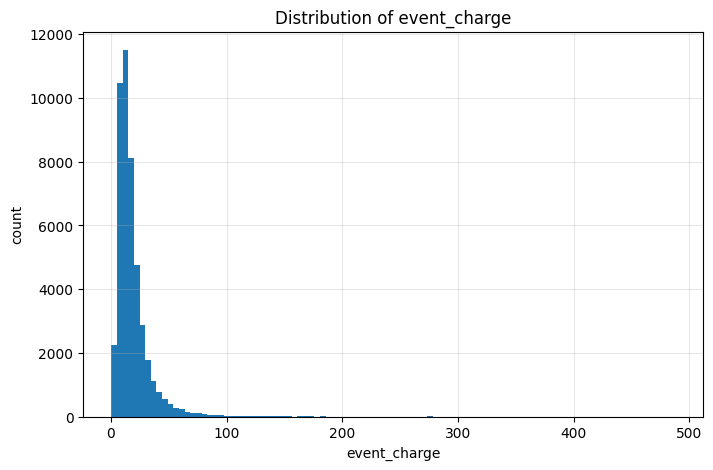

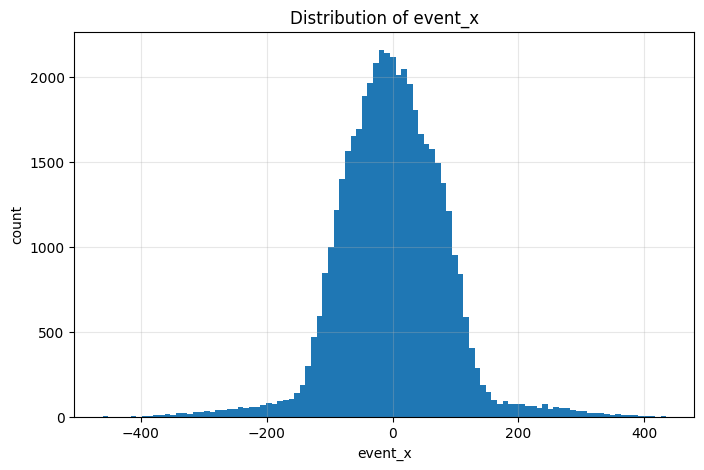

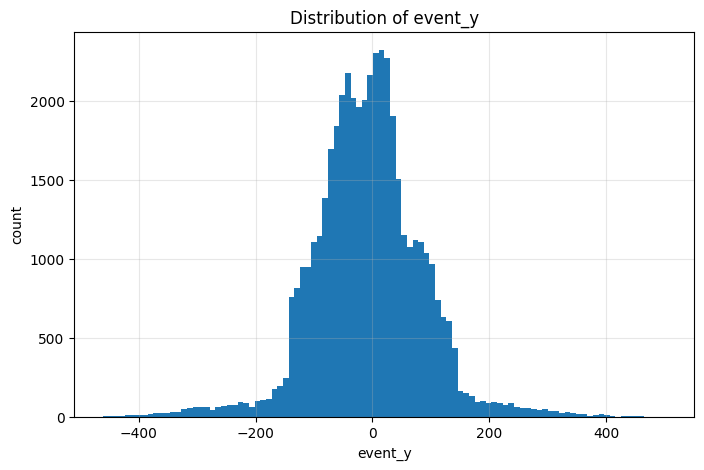

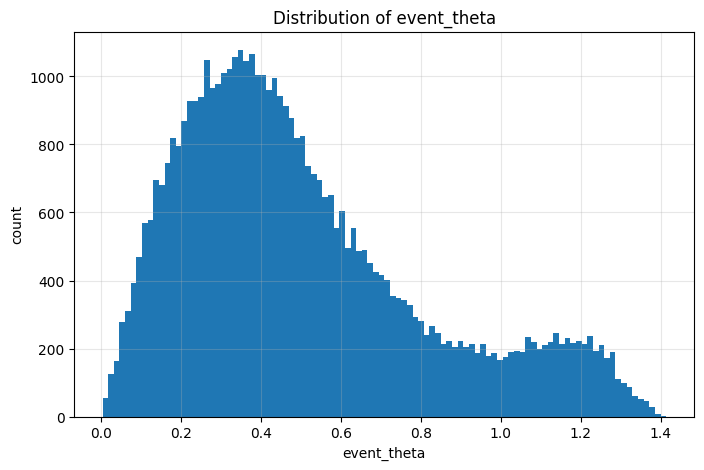

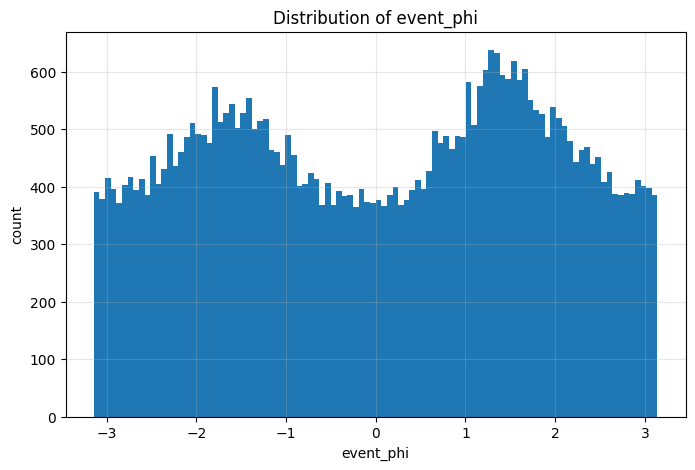

In [5]:
def plot_hist(columns, bins=100, log_y=False, max_rows=MAX_ROWS_FOR_PLOTS):
    columns = [c for c in columns if c in df.columns]
    if not columns:
        print("No requested columns found.")
        return

    for col in columns:
        values = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        if values.empty:
            print(f"{col}: no finite values")
            continue
        if len(values) > max_rows:
            values = values.sample(max_rows, random_state=RANDOM_SEED)

        plt.figure(figsize=(8, 5))
        plt.hist(values, bins=bins)
        if log_y:
            plt.yscale("log")
        plt.xlabel(col)
        plt.ylabel("count")
        plt.title(f"Distribution of {col}")
        plt.grid(True, alpha=0.3)
        plt.show()

plot_hist(
    ["event_charge", "event_x", "event_y", "event_theta", "event_phi", "tt_task5_post"],
    bins=100,
)


## 5. Scatter and hexbin helpers


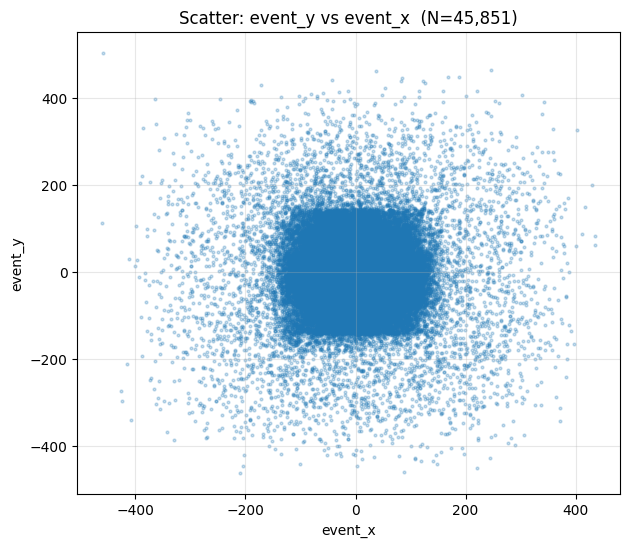

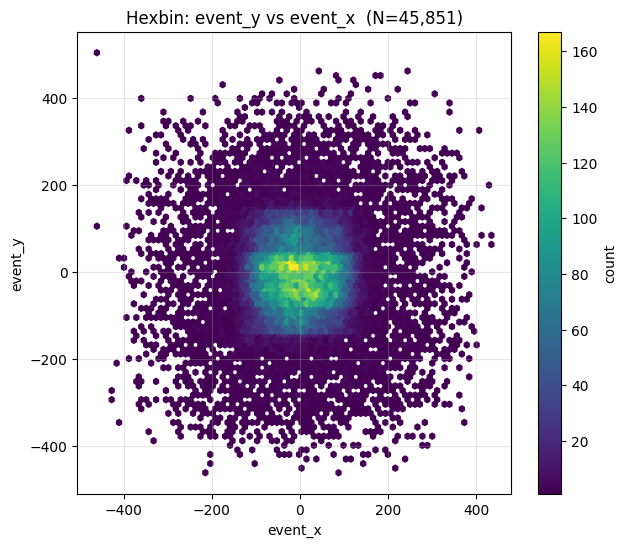

In [6]:
def clean_xy(x_col: str, y_col: str, max_rows: int | None = None) -> pd.DataFrame:
    if x_col not in df.columns or y_col not in df.columns:
        missing = [c for c in [x_col, y_col] if c not in df.columns]
        print(f"Missing column(s): {missing}")
        return pd.DataFrame()

    local = df[[x_col, y_col]].copy()
    local[x_col] = pd.to_numeric(local[x_col], errors="coerce")
    local[y_col] = pd.to_numeric(local[y_col], errors="coerce")
    local = local.replace([np.inf, -np.inf], np.nan).dropna()

    if max_rows is not None and len(local) > max_rows:
        local = local.sample(max_rows, random_state=RANDOM_SEED)

    return local

def scatter_xy(x_col: str, y_col: str, max_rows: int = MAX_ROWS_FOR_SCATTER, alpha: float = 0.25):
    local = clean_xy(x_col, y_col, max_rows=max_rows)
    if local.empty:
        return

    plt.figure(figsize=(7, 6))
    plt.scatter(local[x_col], local[y_col], s=4, alpha=alpha)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"Scatter: {y_col} vs {x_col}  (N={len(local):,})")
    plt.grid(True, alpha=0.3)
    plt.show()

def hexbin_xy(x_col: str, y_col: str, gridsize: int = HEXBIN_GRIDSIZE, mincnt: int = 1):
    local = clean_xy(x_col, y_col, max_rows=MAX_ROWS_FOR_PLOTS)
    if local.empty:
        return

    plt.figure(figsize=(7, 6))
    hb = plt.hexbin(local[x_col], local[y_col], gridsize=gridsize, mincnt=mincnt)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"Hexbin: {y_col} vs {x_col}  (N={len(local):,})")
    plt.colorbar(hb, label="count")
    plt.grid(True, alpha=0.3)
    plt.show()

scatter_xy("event_x", "event_y")
hexbin_xy("event_x", "event_y")


## 6. Configurable comparison groups


In [7]:
# Edit this list freely.
comparison_columns = [
    ["event_x", "event_y", "event_charge"],
    ["event_theta", "event_phi", "p1_s1_qsum", "p1_s2_qsum", "p1_s3_qsum", "p1_s4_qsum"],
    ["p1_qsum", "p2_qsum", "p3_qsum", "p4_qsum"],
    ["p1_tsum", "p2_tsum", "p3_tsum", "p4_tsum"],
    ["p1_ypos", "p2_ypos", "p3_ypos", "p4_ypos"],
    ["tt_task0_raw", "tt_task1_clean", "tt_task2_cal", "tt_task3_list", "tt_task4_fit", "tt_task5_post"],
]

def available_pairs_from_groups(groups):
    pairs = []
    for group_idx, group in enumerate(groups, start=1):
        available = [c for c in group if c in df.columns]
        missing = [c for c in group if c not in df.columns]
        if missing:
            print(f"Group {group_idx}: missing columns skipped: {missing}")

        for x_col, y_col in combinations(available, 2):
            pairs.append((group_idx, x_col, y_col))

    return pairs

pairs = available_pairs_from_groups(comparison_columns)
print(f"Available pairs: {len(pairs)}")
display(pd.DataFrame(pairs, columns=["group", "x", "y"]).head(50))


Group 6: missing columns skipped: ['tt_task5_post']
Available pairs: 46


,group,x,y
0,1,event_x,event_y
1,1,event_x,event_charge
2,1,event_y,event_charge
3,2,event_theta,event_phi
4,2,event_theta,p1_s1_qsum
5,2,event_theta,p1_s2_qsum
6,2,event_theta,p1_s3_qsum
7,2,event_theta,p1_s4_qsum
8,2,event_phi,p1_s1_qsum
9,2,event_phi,p1_s2_qsum


## 7. Plot all pairs in a selected group


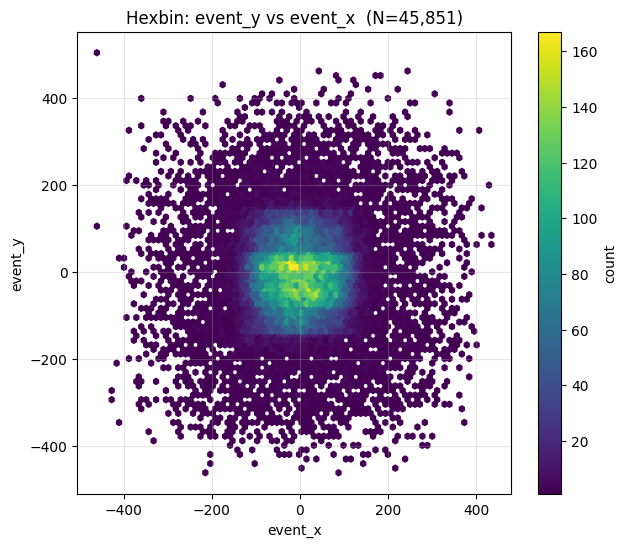

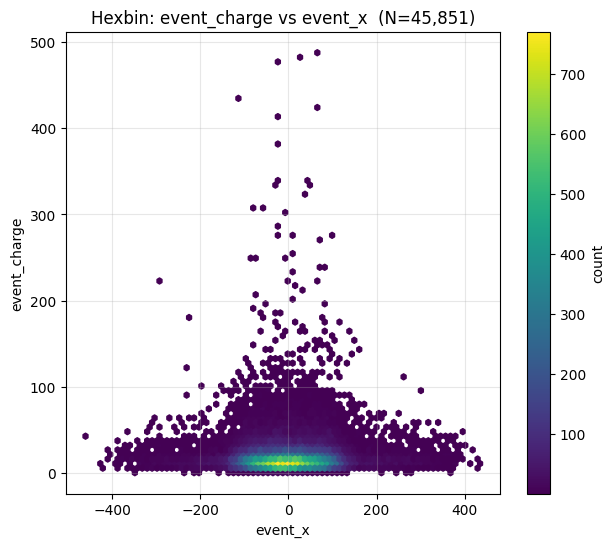

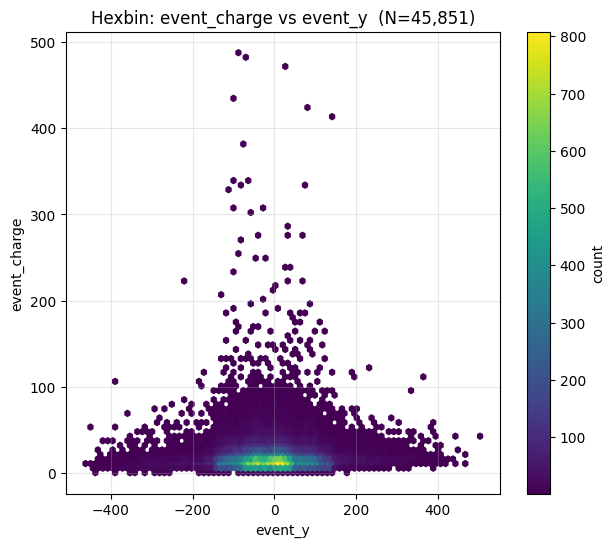

In [8]:
def plot_group(group_index: int, plot_type: str = "hexbin"):
    selected = [(x, y) for g, x, y in pairs if g == group_index]
    if not selected:
        print(f"No pairs available for group {group_index}")
        return

    for x_col, y_col in selected:
        if plot_type == "scatter":
            scatter_xy(x_col, y_col)
        elif plot_type == "hexbin":
            hexbin_xy(x_col, y_col)
        else:
            raise ValueError("plot_type must be 'scatter' or 'hexbin'")

plot_group(1, plot_type="hexbin")
# plot_group(2, plot_type="scatter")


## 8. Time-binned comparison using `tt_task5_post`


Time column not found: tt_task5_post


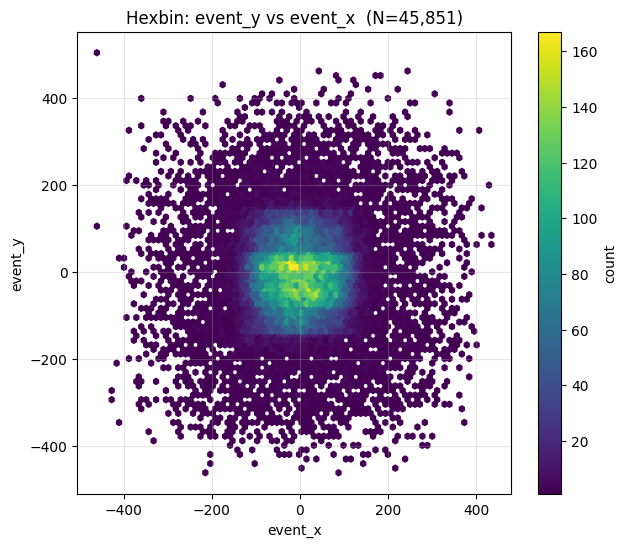

In [9]:
def make_time_bins(time_col: str = "tt_task5_post", n_bins: int = 4) -> pd.Series | None:
    if time_col not in df.columns:
        print(f"Time column not found: {time_col}")
        return None

    t = pd.to_numeric(df[time_col], errors="coerce").replace([np.inf, -np.inf], np.nan)
    valid = t.dropna()

    if valid.empty:
        print(f"Time column has no finite values: {time_col}")
        return None

    bins = pd.qcut(t, q=n_bins, duplicates="drop")
    print(f"Created {bins.dropna().nunique()} time bins from {time_col}")
    return bins

def time_binned_hexbin(
    x_col: str,
    y_col: str,
    time_col: str = "tt_task5_post",
    n_bins: int = 4,
    gridsize: int = HEXBIN_GRIDSIZE,
):
    if x_col not in df.columns or y_col not in df.columns:
        print(f"Missing x/y column: {x_col}, {y_col}")
        return

    bins = make_time_bins(time_col, n_bins)
    if bins is None:
        hexbin_xy(x_col, y_col, gridsize=gridsize)
        return

    local = df[[x_col, y_col]].copy()
    local[x_col] = pd.to_numeric(local[x_col], errors="coerce")
    local[y_col] = pd.to_numeric(local[y_col], errors="coerce")
    local["_time_bin"] = bins
    local = local.replace([np.inf, -np.inf], np.nan).dropna(subset=[x_col, y_col, "_time_bin"])

    if local.empty:
        print("No finite rows for time-binned plot.")
        return

    if len(local) > MAX_ROWS_FOR_PLOTS:
        local = local.sample(MAX_ROWS_FOR_PLOTS, random_state=RANDOM_SEED)

    xlim = (local[x_col].min(), local[x_col].max())
    ylim = (local[y_col].min(), local[y_col].max())

    unique_bins = list(local["_time_bin"].cat.categories)
    n = len(unique_bins)
    ncols = min(2, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5.5 * nrows), squeeze=False)

    for ax, bin_value in zip(axes.ravel(), unique_bins):
        sub = local[local["_time_bin"] == bin_value]
        if sub.empty:
            ax.text(0.5, 0.5, "empty", ha="center", va="center", transform=ax.transAxes)
        else:
            hb = ax.hexbin(sub[x_col], sub[y_col], gridsize=gridsize, mincnt=1)
            fig.colorbar(hb, ax=ax, label="count")

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(f"{bin_value}\\nN={len(sub):,}")
        ax.grid(True, alpha=0.3)

    for ax in axes.ravel()[n:]:
        ax.axis("off")

    fig.suptitle(f"Time-binned hexbin: {y_col} vs {x_col}, binned by {time_col}", y=1.02)
    fig.tight_layout()
    plt.show()

def time_binned_scatter(
    x_col: str,
    y_col: str,
    time_col: str = "tt_task5_post",
    n_bins: int = 4,
    max_rows: int = MAX_ROWS_FOR_SCATTER,
):
    if x_col not in df.columns or y_col not in df.columns:
        print(f"Missing x/y column: {x_col}, {y_col}")
        return

    bins = make_time_bins(time_col, n_bins)
    if bins is None:
        scatter_xy(x_col, y_col, max_rows=max_rows)
        return

    local = df[[x_col, y_col]].copy()
    local[x_col] = pd.to_numeric(local[x_col], errors="coerce")
    local[y_col] = pd.to_numeric(local[y_col], errors="coerce")
    local["_time_bin"] = bins
    local = local.replace([np.inf, -np.inf], np.nan).dropna(subset=[x_col, y_col, "_time_bin"])

    if local.empty:
        print("No finite rows for time-binned plot.")
        return

    if len(local) > max_rows:
        local = local.sample(max_rows, random_state=RANDOM_SEED)

    xlim = (local[x_col].min(), local[x_col].max())
    ylim = (local[y_col].min(), local[y_col].max())

    unique_bins = list(local["_time_bin"].cat.categories)
    n = len(unique_bins)
    ncols = min(2, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5.5 * nrows), squeeze=False)

    for ax, bin_value in zip(axes.ravel(), unique_bins):
        sub = local[local["_time_bin"] == bin_value]
        if sub.empty:
            ax.text(0.5, 0.5, "empty", ha="center", va="center", transform=ax.transAxes)
        else:
            ax.scatter(sub[x_col], sub[y_col], s=4, alpha=0.25)

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(f"{bin_value}\\nN={len(sub):,}")
        ax.grid(True, alpha=0.3)

    for ax in axes.ravel()[n:]:
        ax.axis("off")

    fig.suptitle(f"Time-binned scatter: {y_col} vs {x_col}, binned by {time_col}", y=1.02)
    fig.tight_layout()
    plt.show()

time_binned_hexbin("event_x", "event_y", time_col="tt_task5_post", n_bins=4)
# time_binned_scatter("event_theta", "event_phi", time_col="tt_task5_post", n_bins=4)


## 9. Correlation matrix


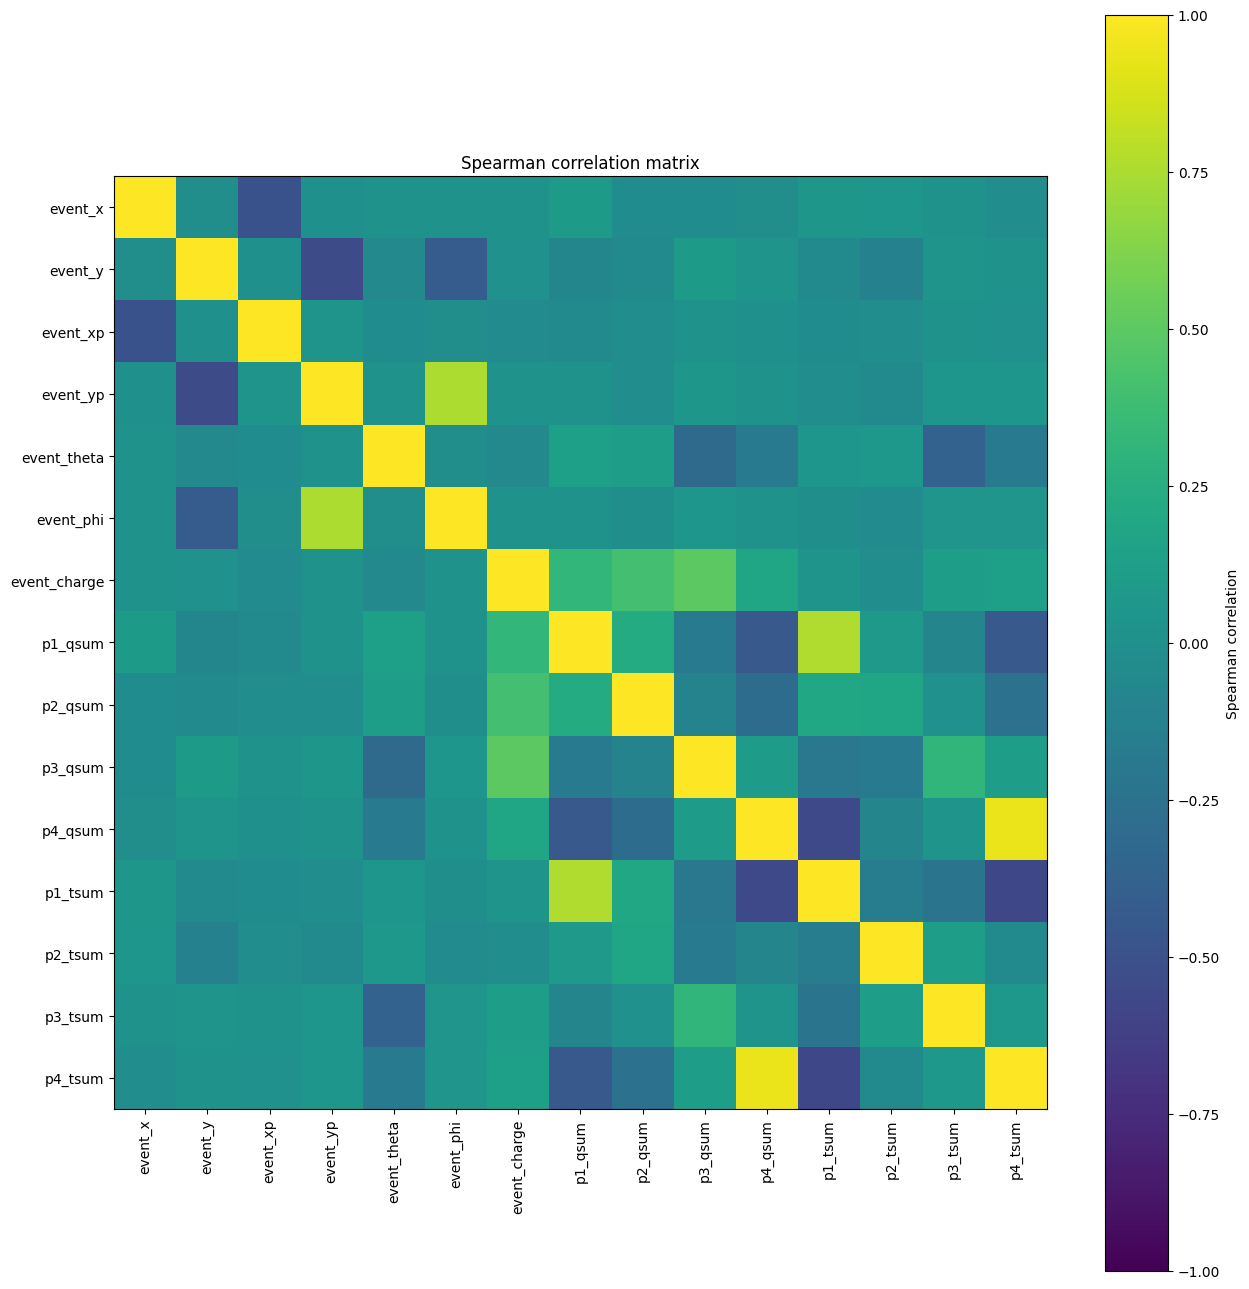

,event_x,event_y,event_xp,event_yp,event_theta,event_phi,event_charge,p1_qsum,p2_qsum,p3_qsum,p4_qsum,p1_tsum,p2_tsum,p3_tsum,p4_tsum
event_x,1.000000,-0.009279,-0.493955,0.000630,0.031193,0.027549,0.021854,0.086877,-0.023701,-0.028638,-0.010934,0.056577,0.053024,0.025008,-0.021980
event_y,-0.009279,1.000000,0.001856,-0.545311,-0.061790,-0.418728,0.014153,-0.083255,-0.048975,0.091538,0.036635,-0.039813,-0.119153,0.035948,0.029186
event_xp,-0.493955,0.001856,1.000000,0.031545,-0.031178,-0.008142,-0.034020,-0.051954,-0.019538,0.024354,0.001238,-0.028664,-0.020710,0.022851,0.014469
event_yp,0.000630,-0.545311,0.031545,1.000000,0.018226,0.752169,0.027933,0.020574,-0.019460,0.061859,0.019486,-0.018641,-0.050124,0.051073,0.049619
event_theta,0.031193,-0.061790,-0.031178,0.018226,1.000000,-0.009916,-0.055220,0.132586,0.122525,-0.306092,-0.167513,0.047804,0.069551,-0.374207,-0.173236
event_phi,0.027549,-0.418728,-0.008142,0.752169,-0.009916,1.000000,0.027865,0.022144,-0.007585,0.048811,0.018205,-0.003221,-0.037714,0.040242,0.044055
event_charge,0.021854,0.014153,-0.034020,0.027933,-0.055220,0.027865,1.000000,0.324224,0.404768,0.498923,0.177895,0.036558,-0.018246,0.118901,0.125064
p1_qsum,0.086877,-0.083255,-0.051954,0.020574,0.132586,0.022144,0.324224,1.000000,0.228913,-0.186866,-0.444244,0.758302,0.079116,-0.088917,-0.440682
p2_qsum,-0.023701,-0.048975,-0.019538,-0.019460,0.122525,-0.007585,0.404768,0.228913,1.000000,-0.108825,-0.289399,0.189541,0.183549,0.008028,-0.256759
p3_qsum,-0.028638,0.091538,0.024354,0.061859,-0.306092,0.048811,0.498923,-0.186866,-0.108825,1.000000,0.106988,-0.196512,-0.186673,0.318874,0.114599


In [10]:
corr_columns = [
    "event_x", "event_y", "event_xp", "event_yp",
    "event_theta", "event_phi", "event_charge",
    "p1_qsum", "p2_qsum", "p3_qsum", "p4_qsum",
    "p1_tsum", "p2_tsum", "p3_tsum", "p4_tsum",
    "tt_task5_post",
]

def plot_corr_matrix(columns):
    columns = [c for c in columns if c in df.columns]
    if len(columns) < 2:
        print("Need at least two available columns.")
        return

    local = df[columns].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

    if len(local) > MAX_ROWS_FOR_PLOTS:
        local = local.sample(MAX_ROWS_FOR_PLOTS, random_state=RANDOM_SEED)

    corr = local.corr(method="spearman", min_periods=100)

    plt.figure(figsize=(0.6 * len(columns) + 4, 0.6 * len(columns) + 4))
    im = plt.imshow(corr, vmin=-1, vmax=1)
    plt.xticks(range(len(columns)), columns, rotation=90)
    plt.yticks(range(len(columns)), columns)
    plt.colorbar(im, label="Spearman correlation")
    plt.title("Spearman correlation matrix")
    plt.tight_layout()
    plt.show()

    display(corr)

plot_corr_matrix(corr_columns)


## 10. Plane and strip quick-look plots


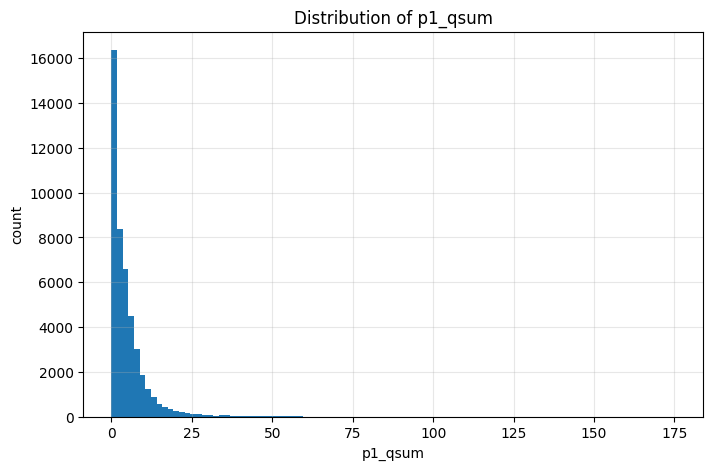

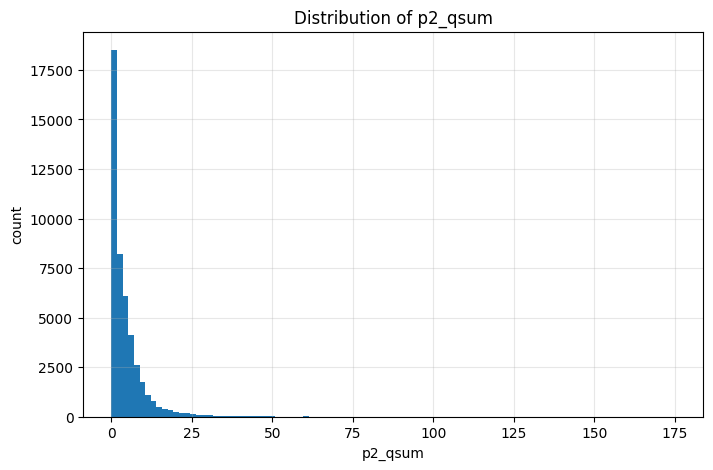

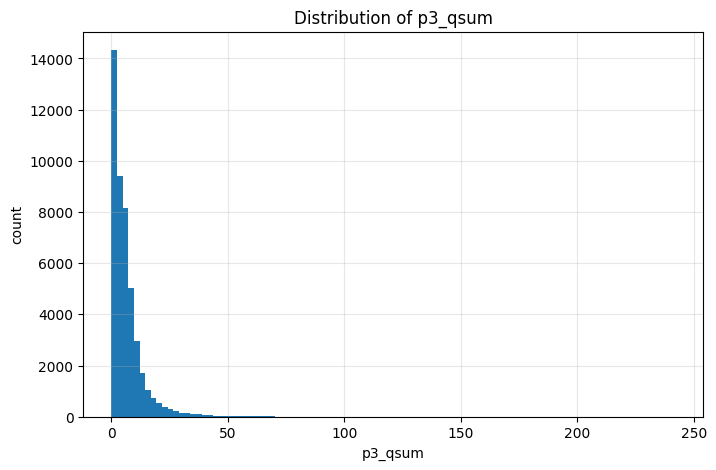

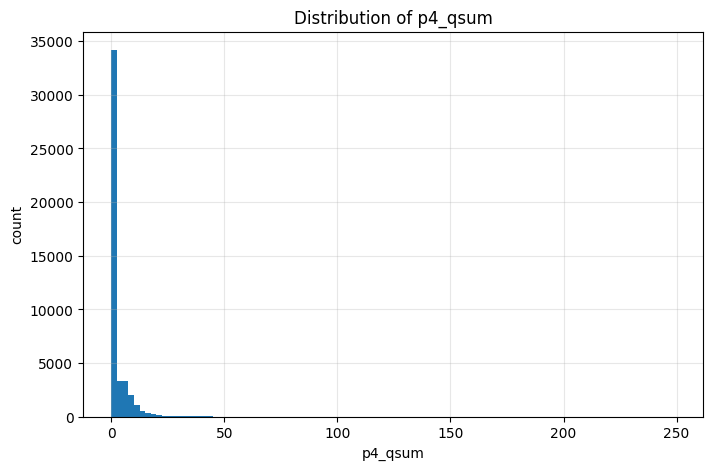

In [15]:
def plot_plane_quantity(quantity: str):
    cols = [f"p{i}_{quantity}" for i in range(1, 5) if f"p{i}_{quantity}" in df.columns]
    if not cols:
        print(f"No plane columns found for quantity: {quantity}")
        return
    plot_hist(cols, bins=100, log_y=False)

plot_plane_quantity("qsum")

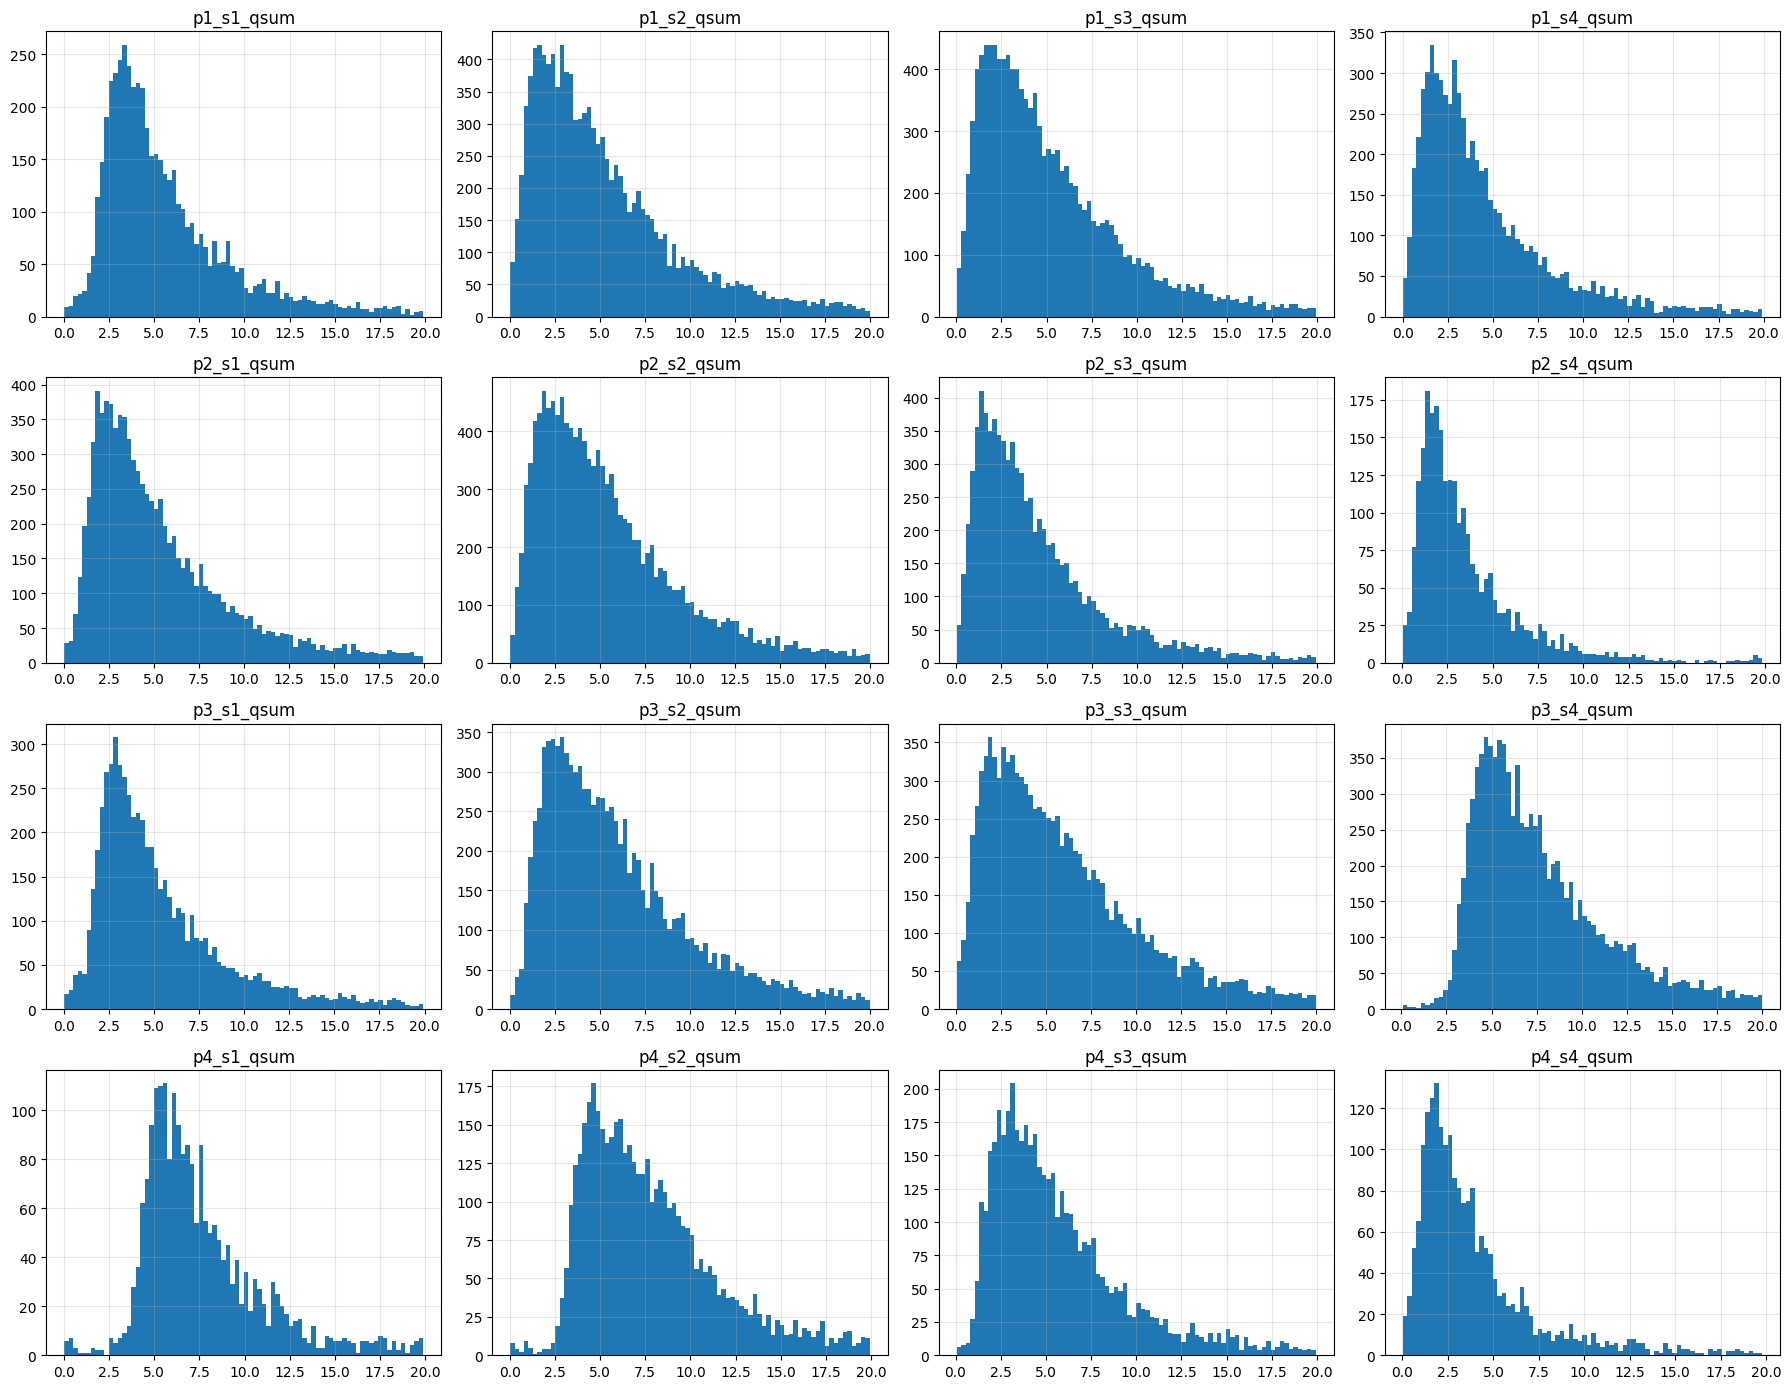

In [17]:

def plot_strip_quantity_grid(quantity: str, bins=80):
    cols = []
    for plane in range(1, 5):
        for strip in range(1, 5):
            col = f"p{plane}_s{strip}_{quantity}"
            if col in df.columns:
                cols.append((plane, strip, col))

    if not cols:
        print(f"No strip columns found for quantity: {quantity}")
        return

    fig, axes = plt.subplots(4, 4, figsize=(18, 14), squeeze=False)

    for plane, strip, col in cols:
        ax = axes[plane - 1][strip - 1]
        values = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        if len(values) > MAX_ROWS_FOR_PLOTS:
            values = values.sample(MAX_ROWS_FOR_PLOTS, random_state=RANDOM_SEED)
        values = values[values > 0]
        values = values[values < 20]
        ax.hist(values, bins=bins)
        ax.set_title(col)
        ax.grid(True, alpha=0.3)

    for ax in axes.ravel():
        if not ax.get_title():
            ax.axis("off")

    fig.tight_layout()
    plt.show()

plot_strip_quantity_grid("qsum")


Found 11 unique values in tt_task4_fit


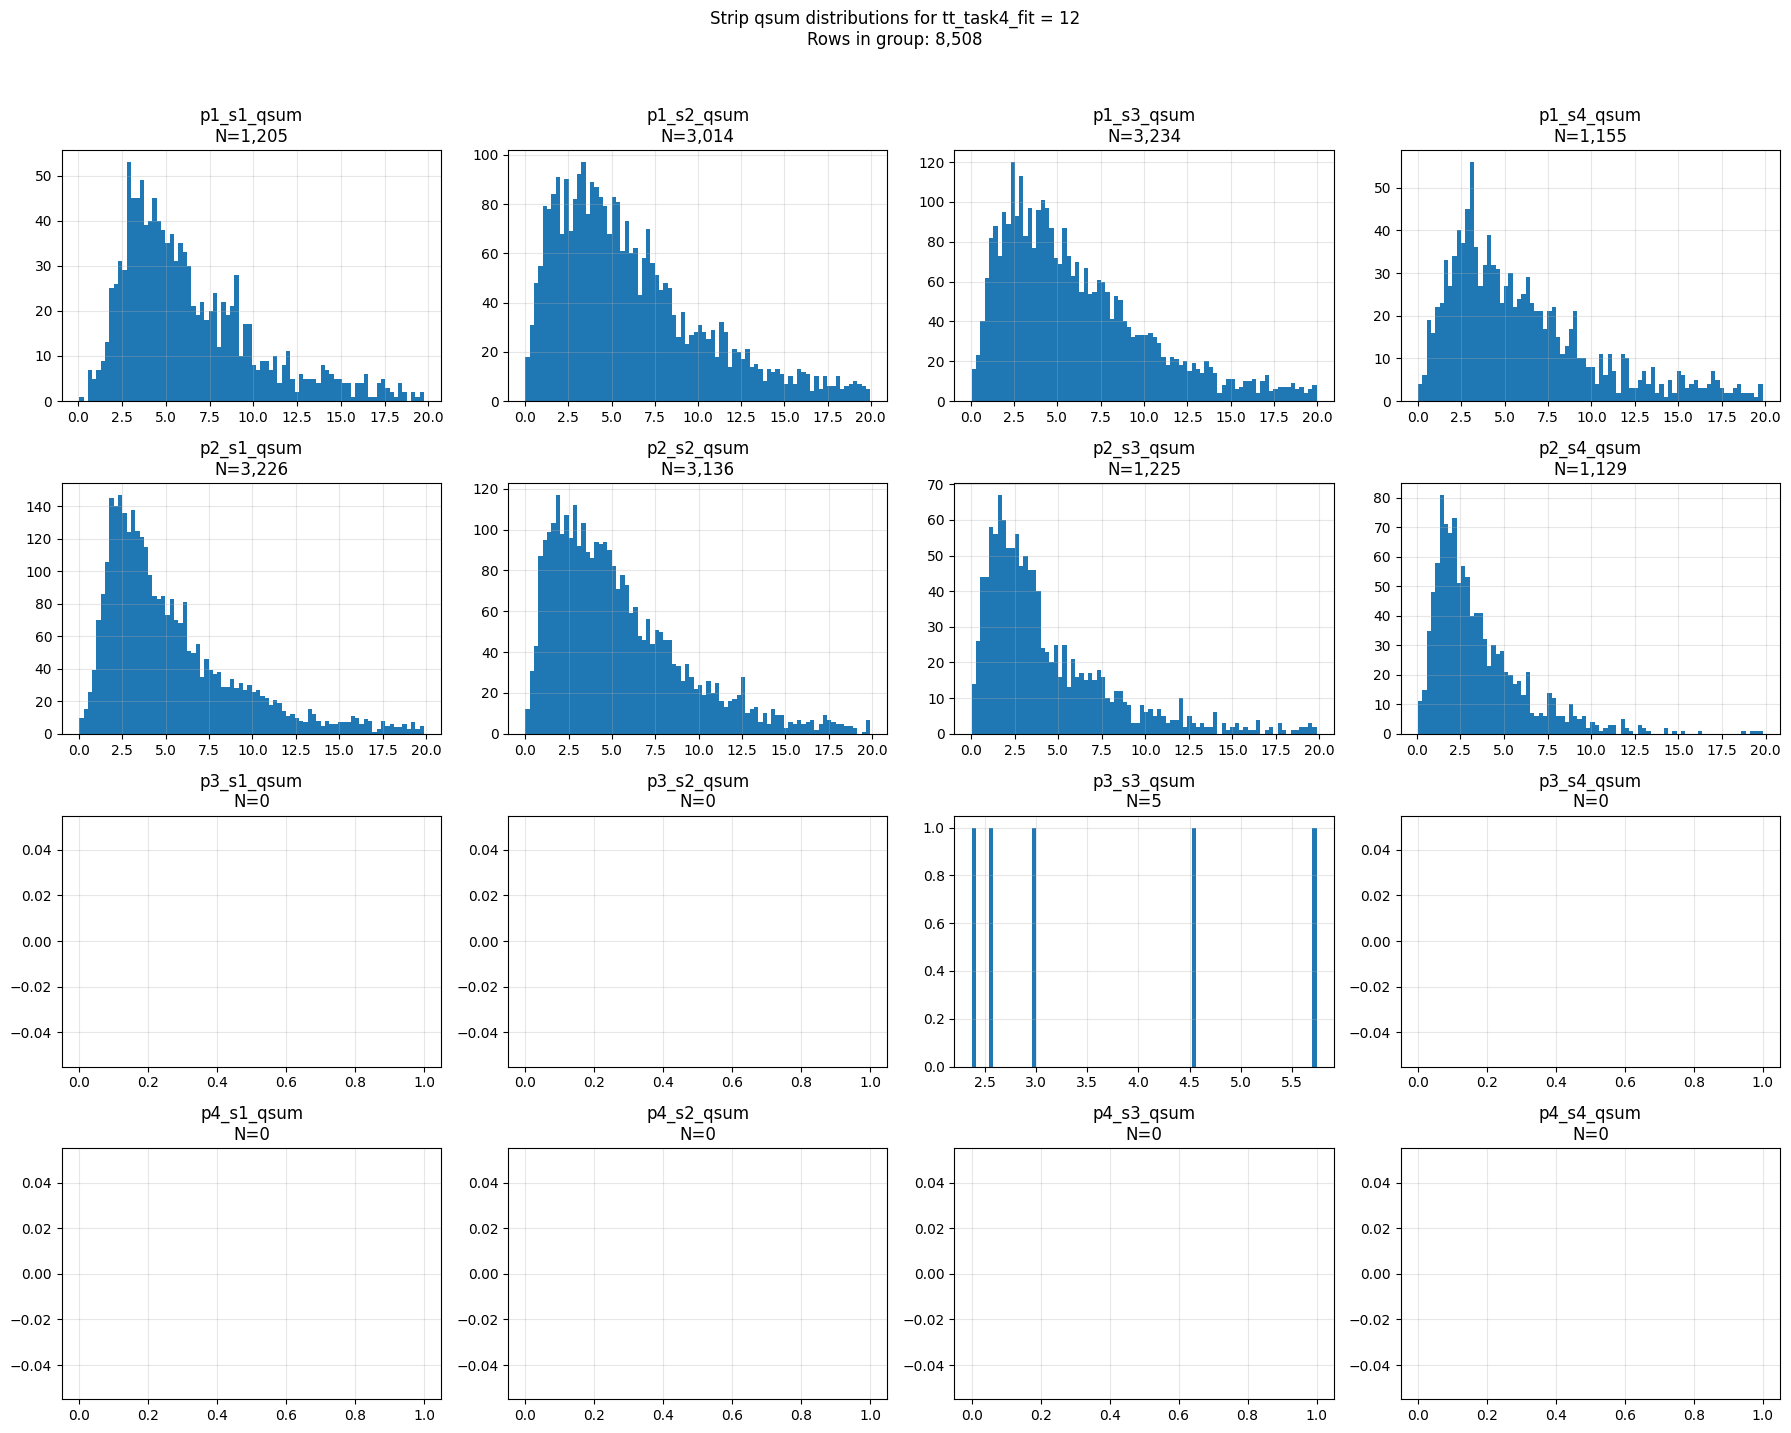

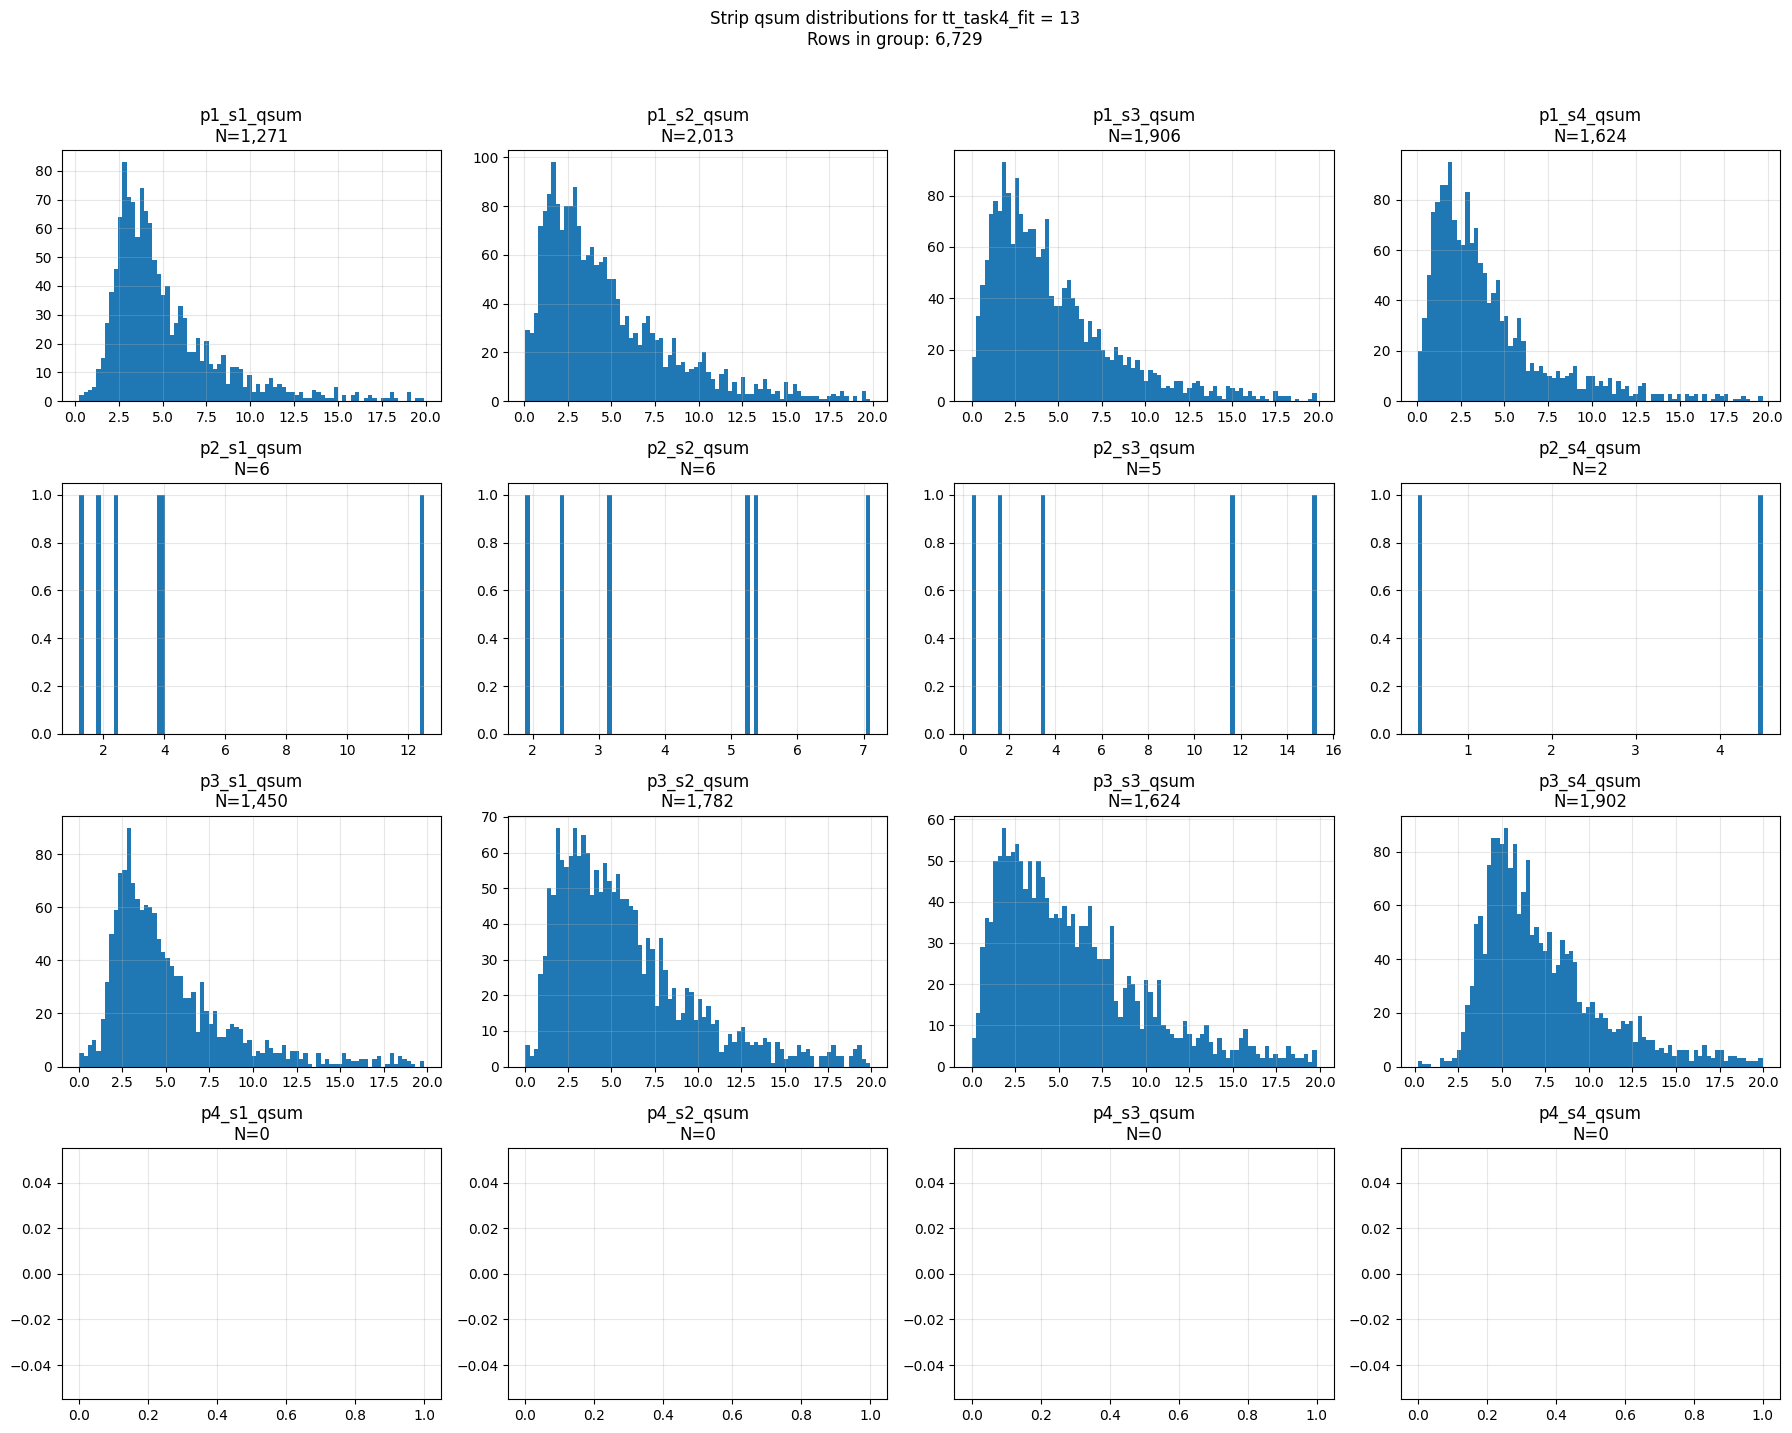

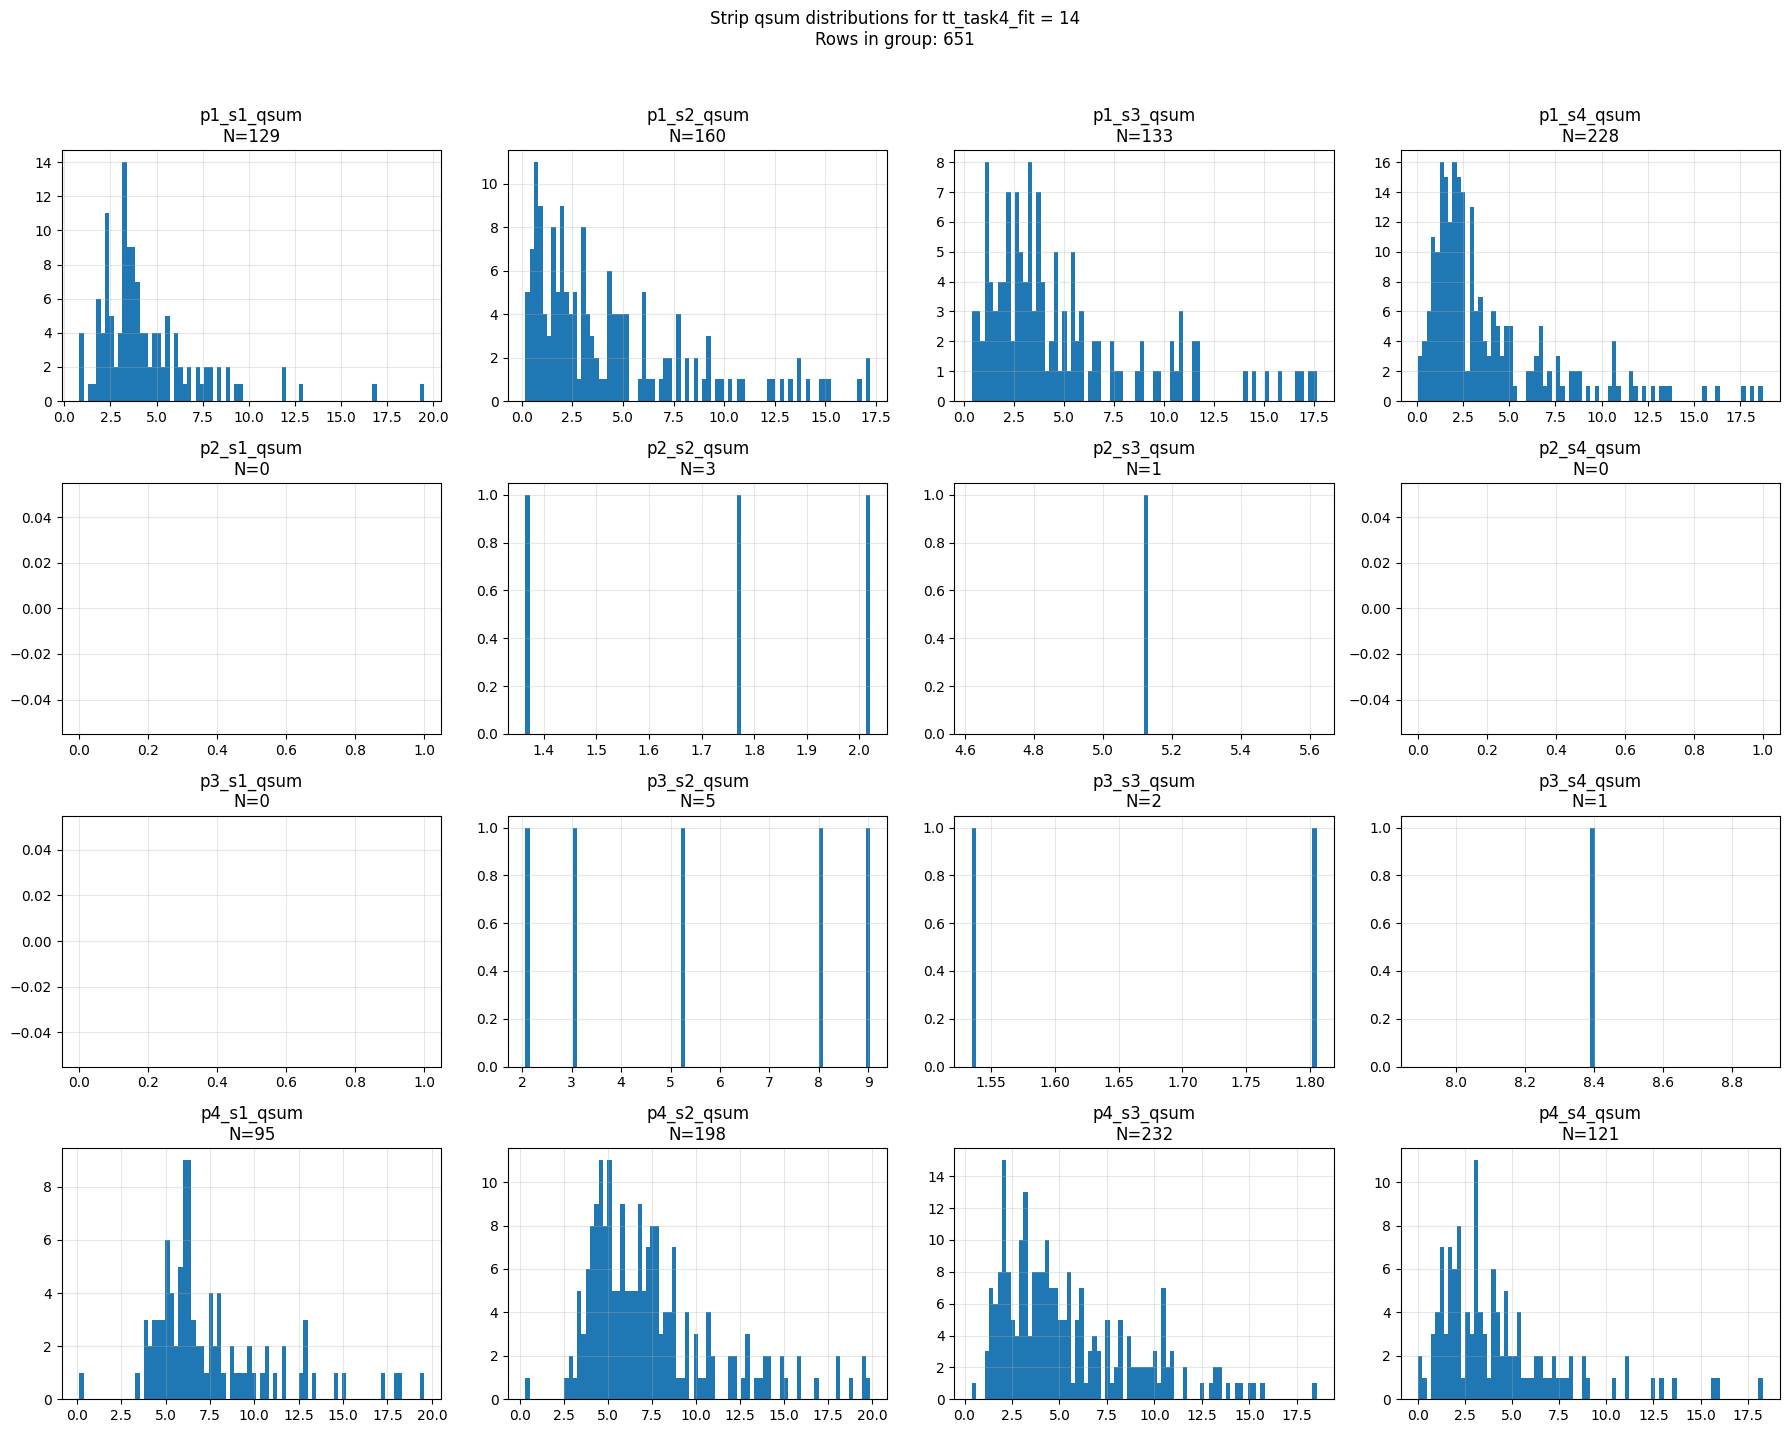

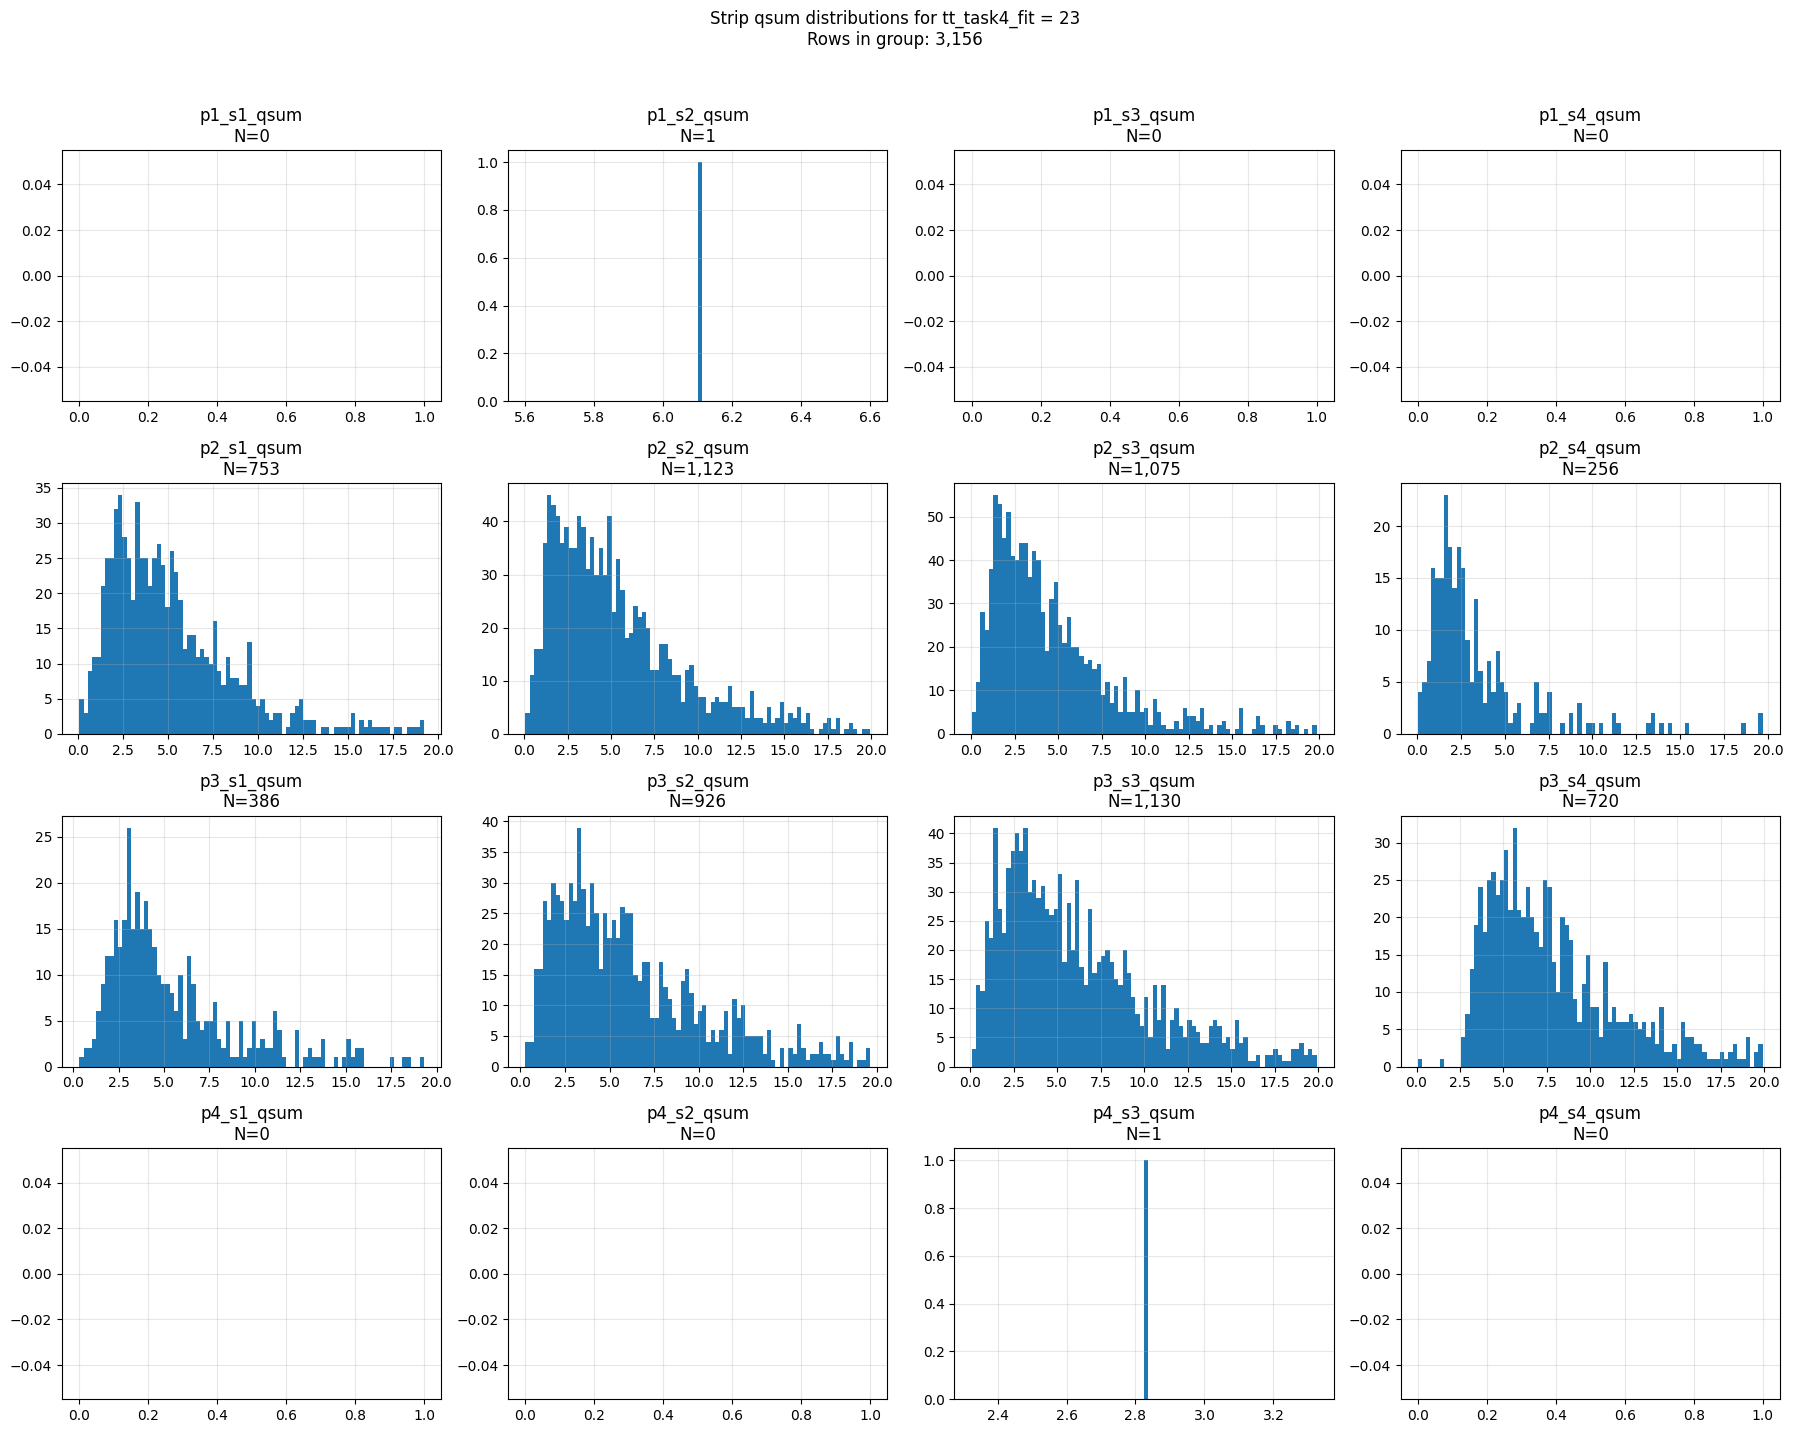

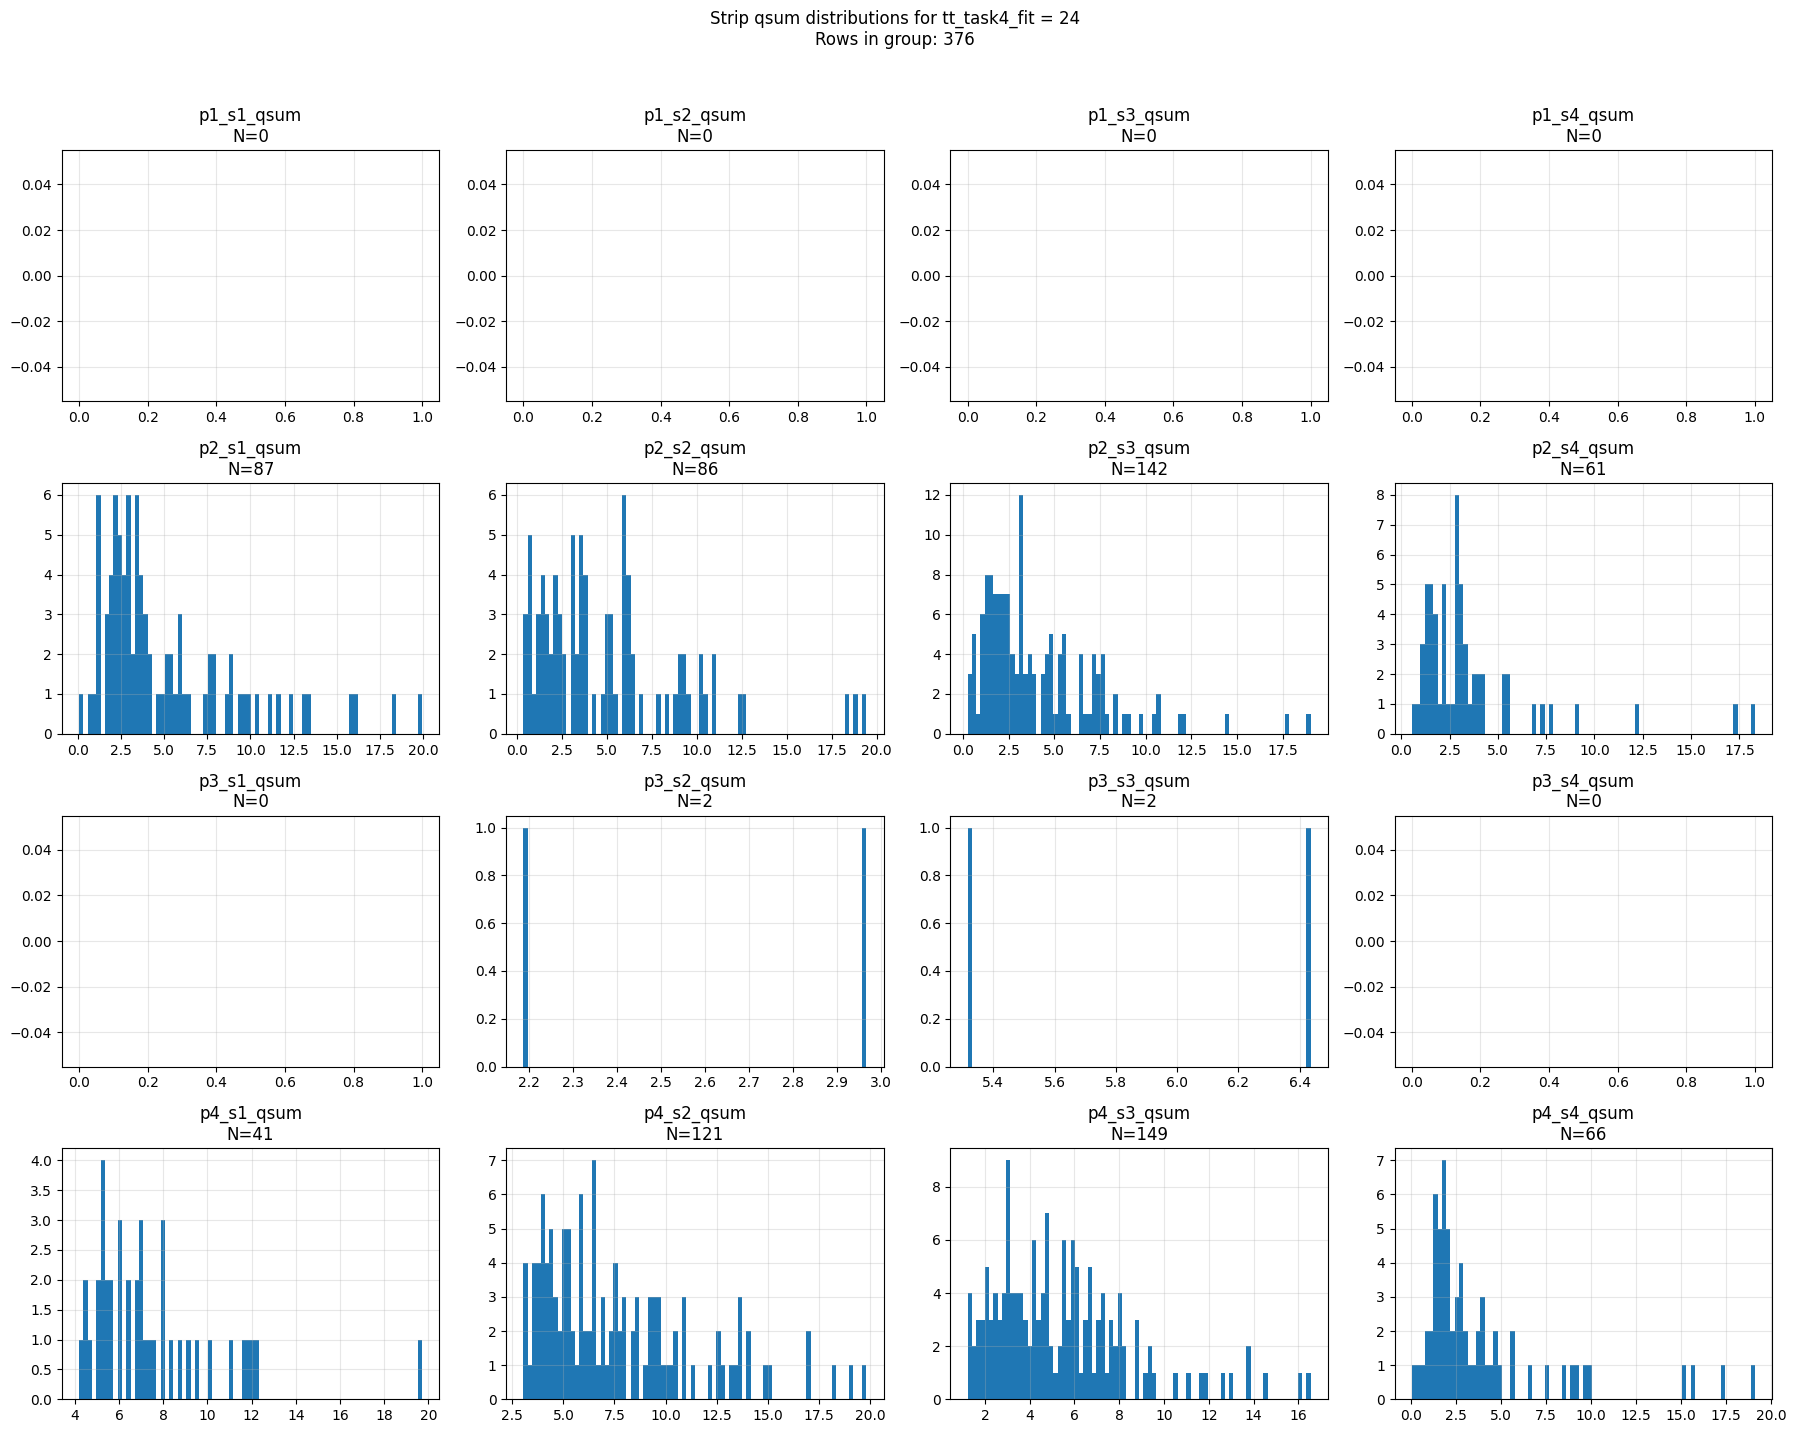

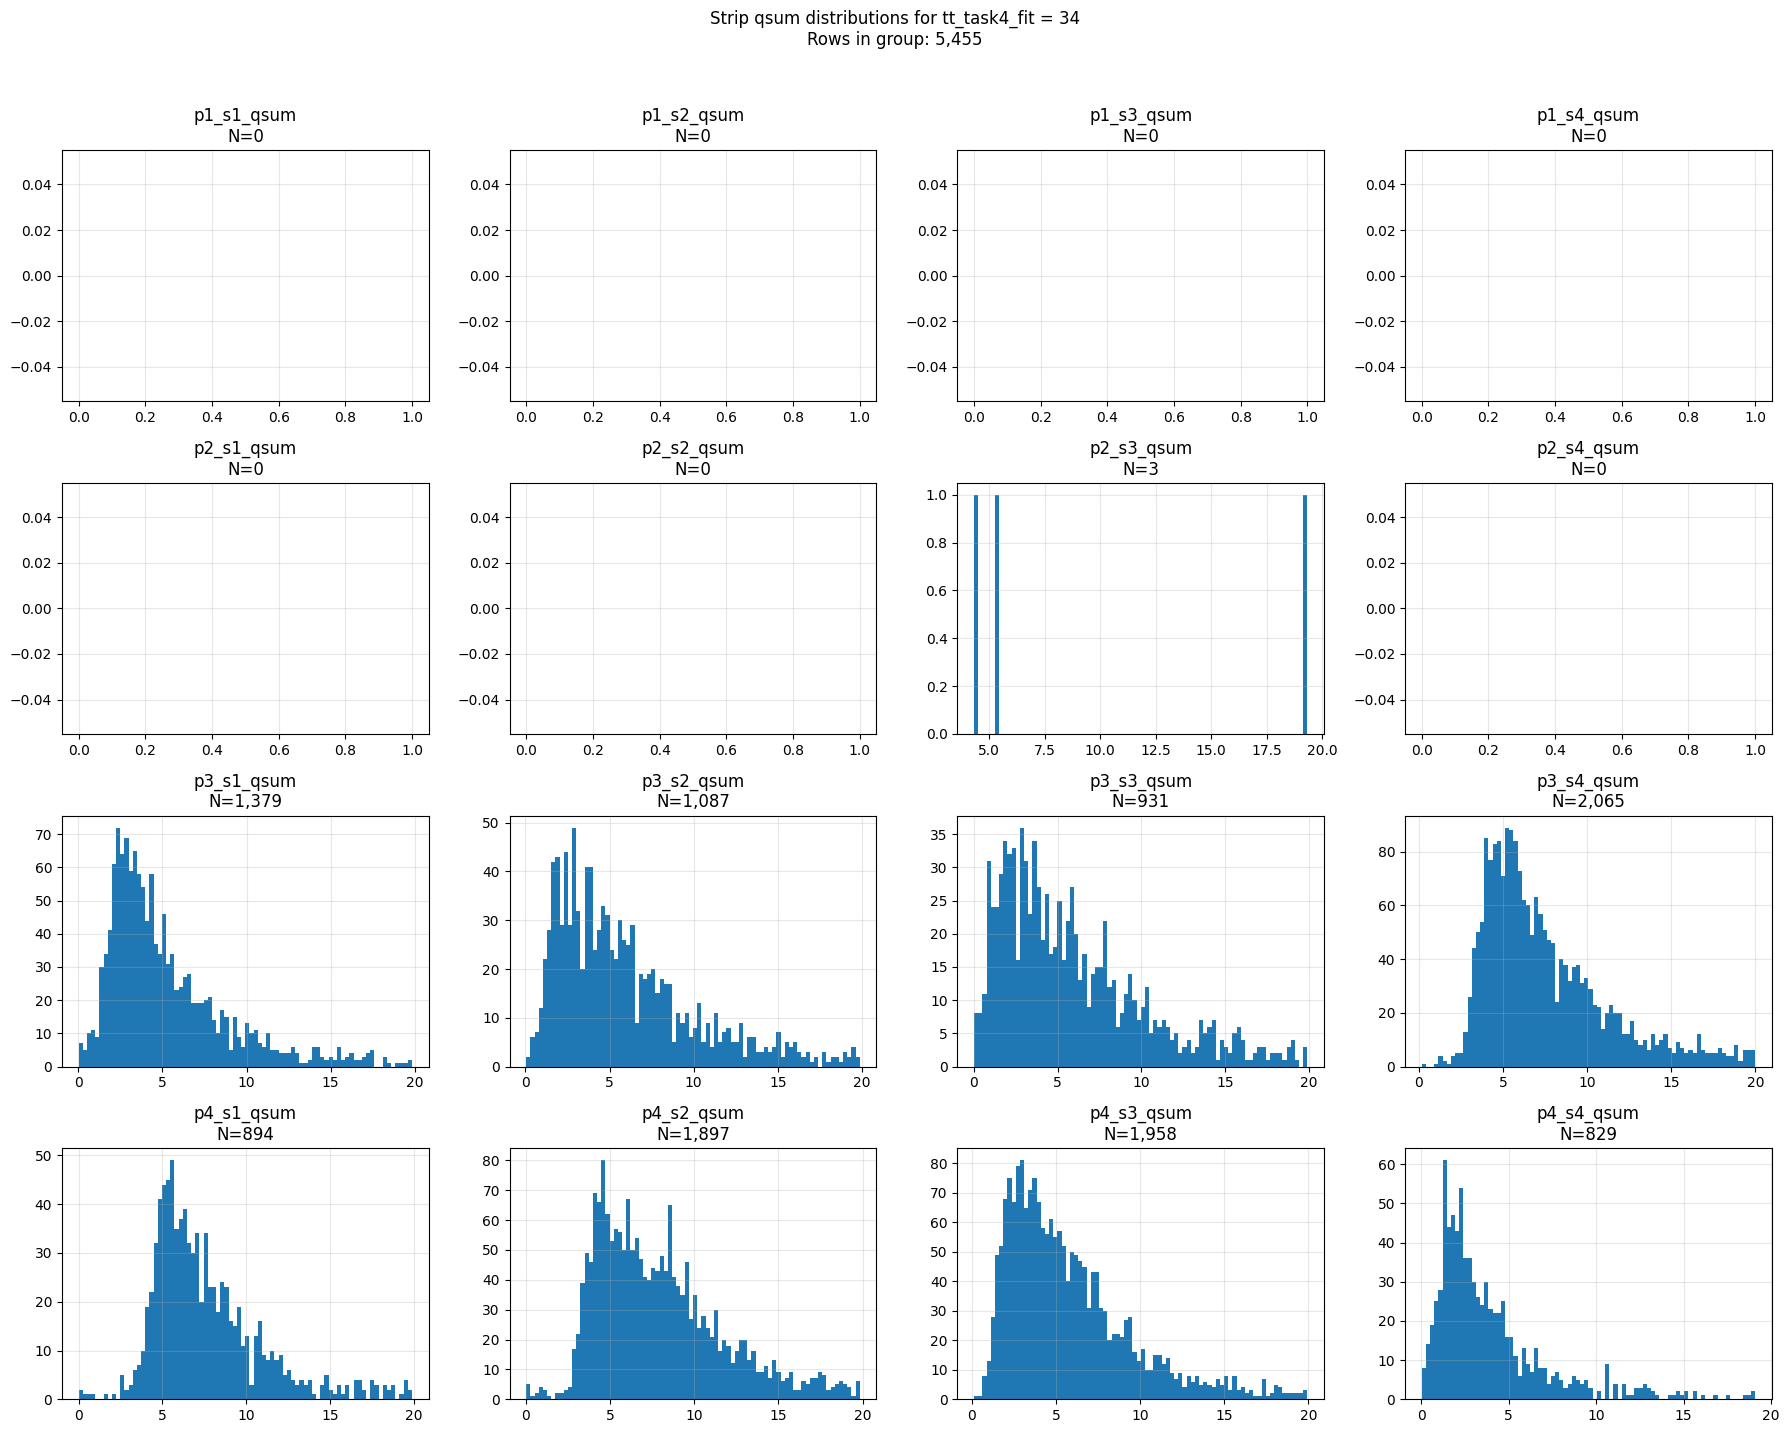

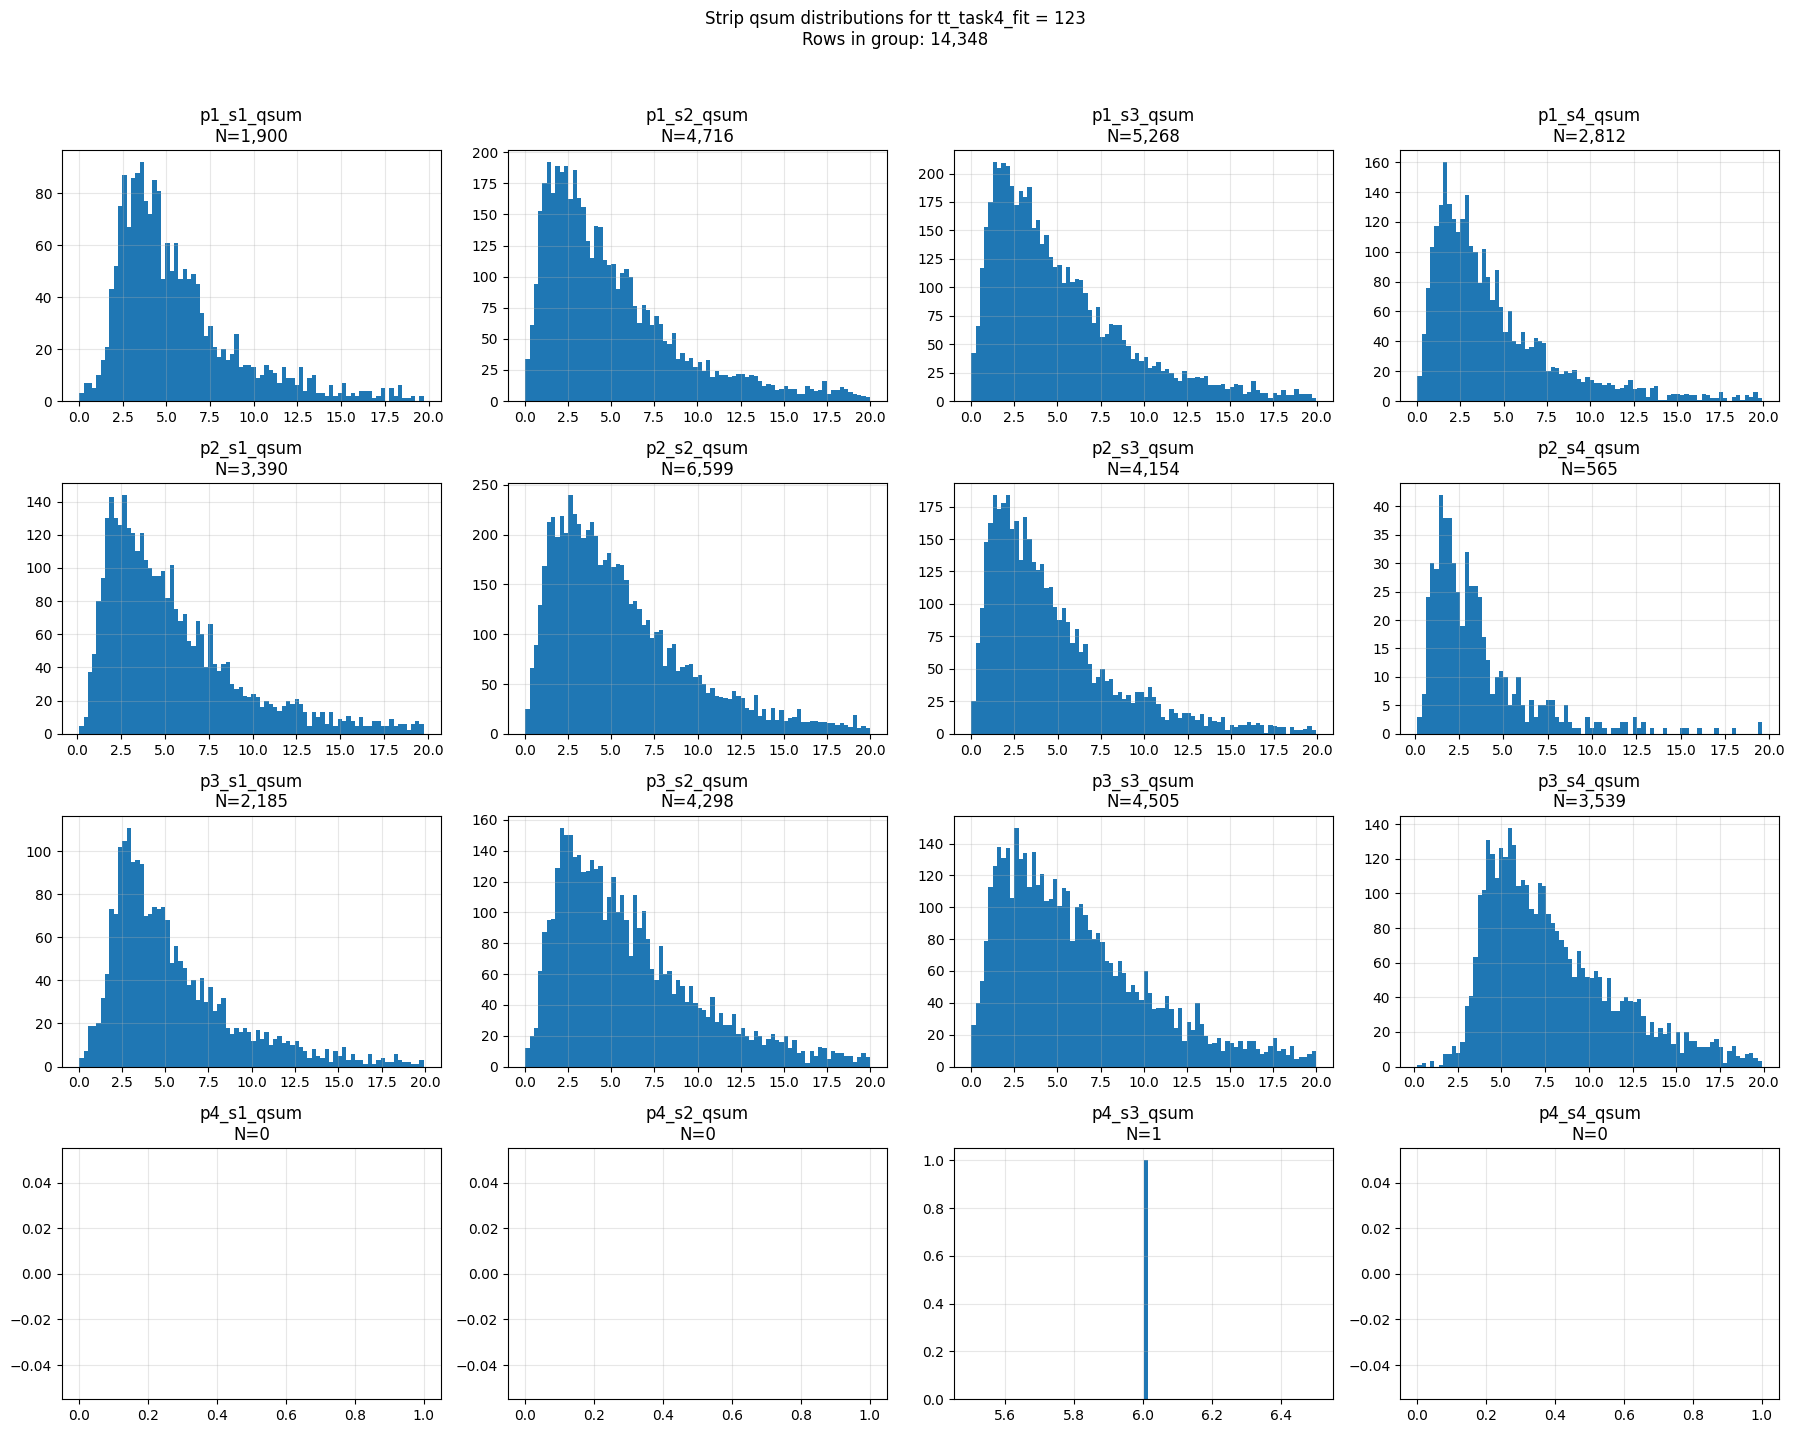

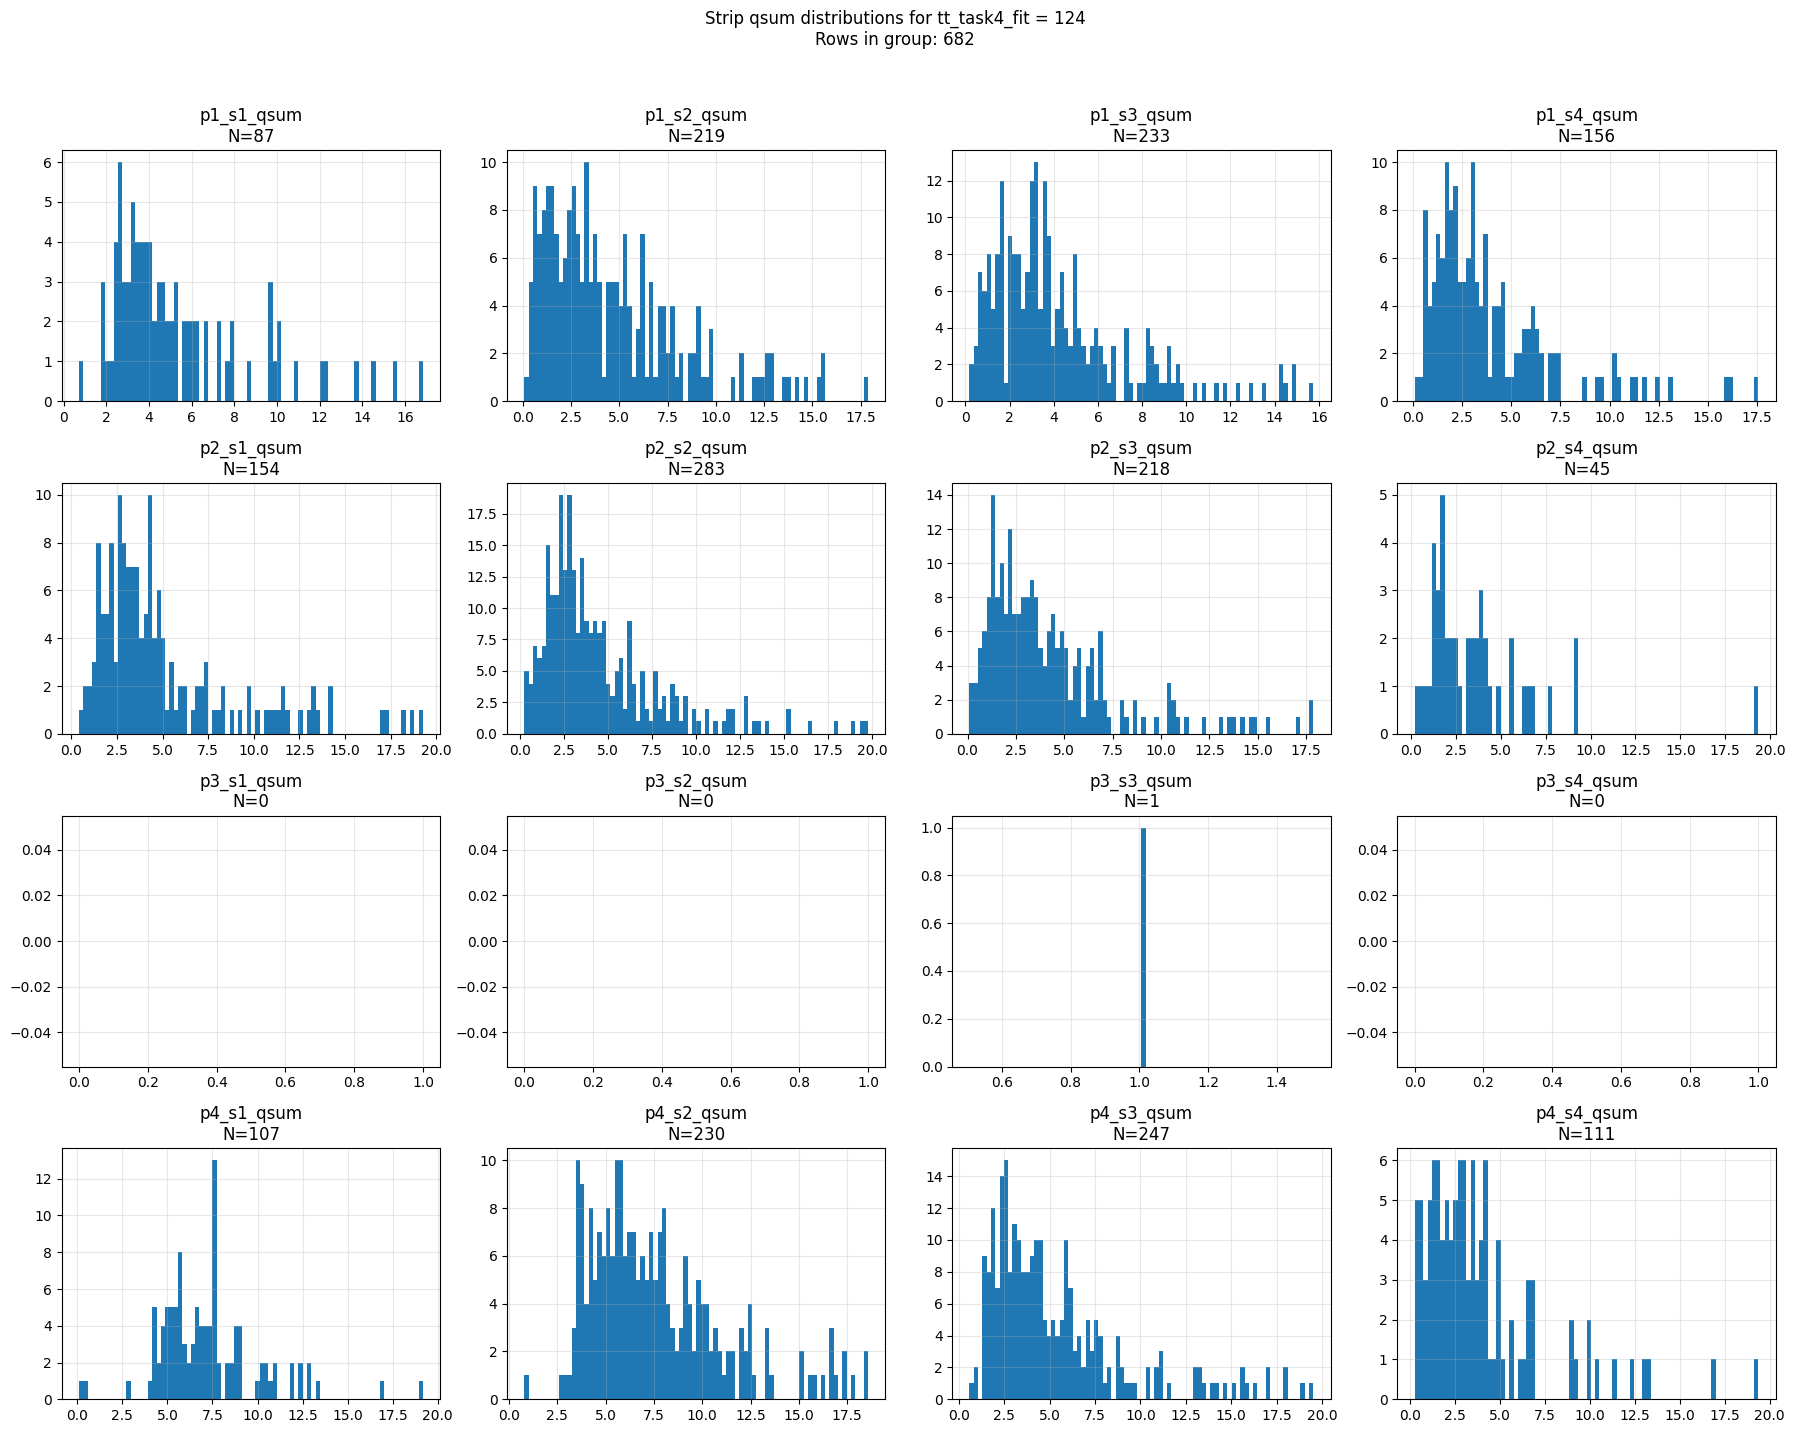

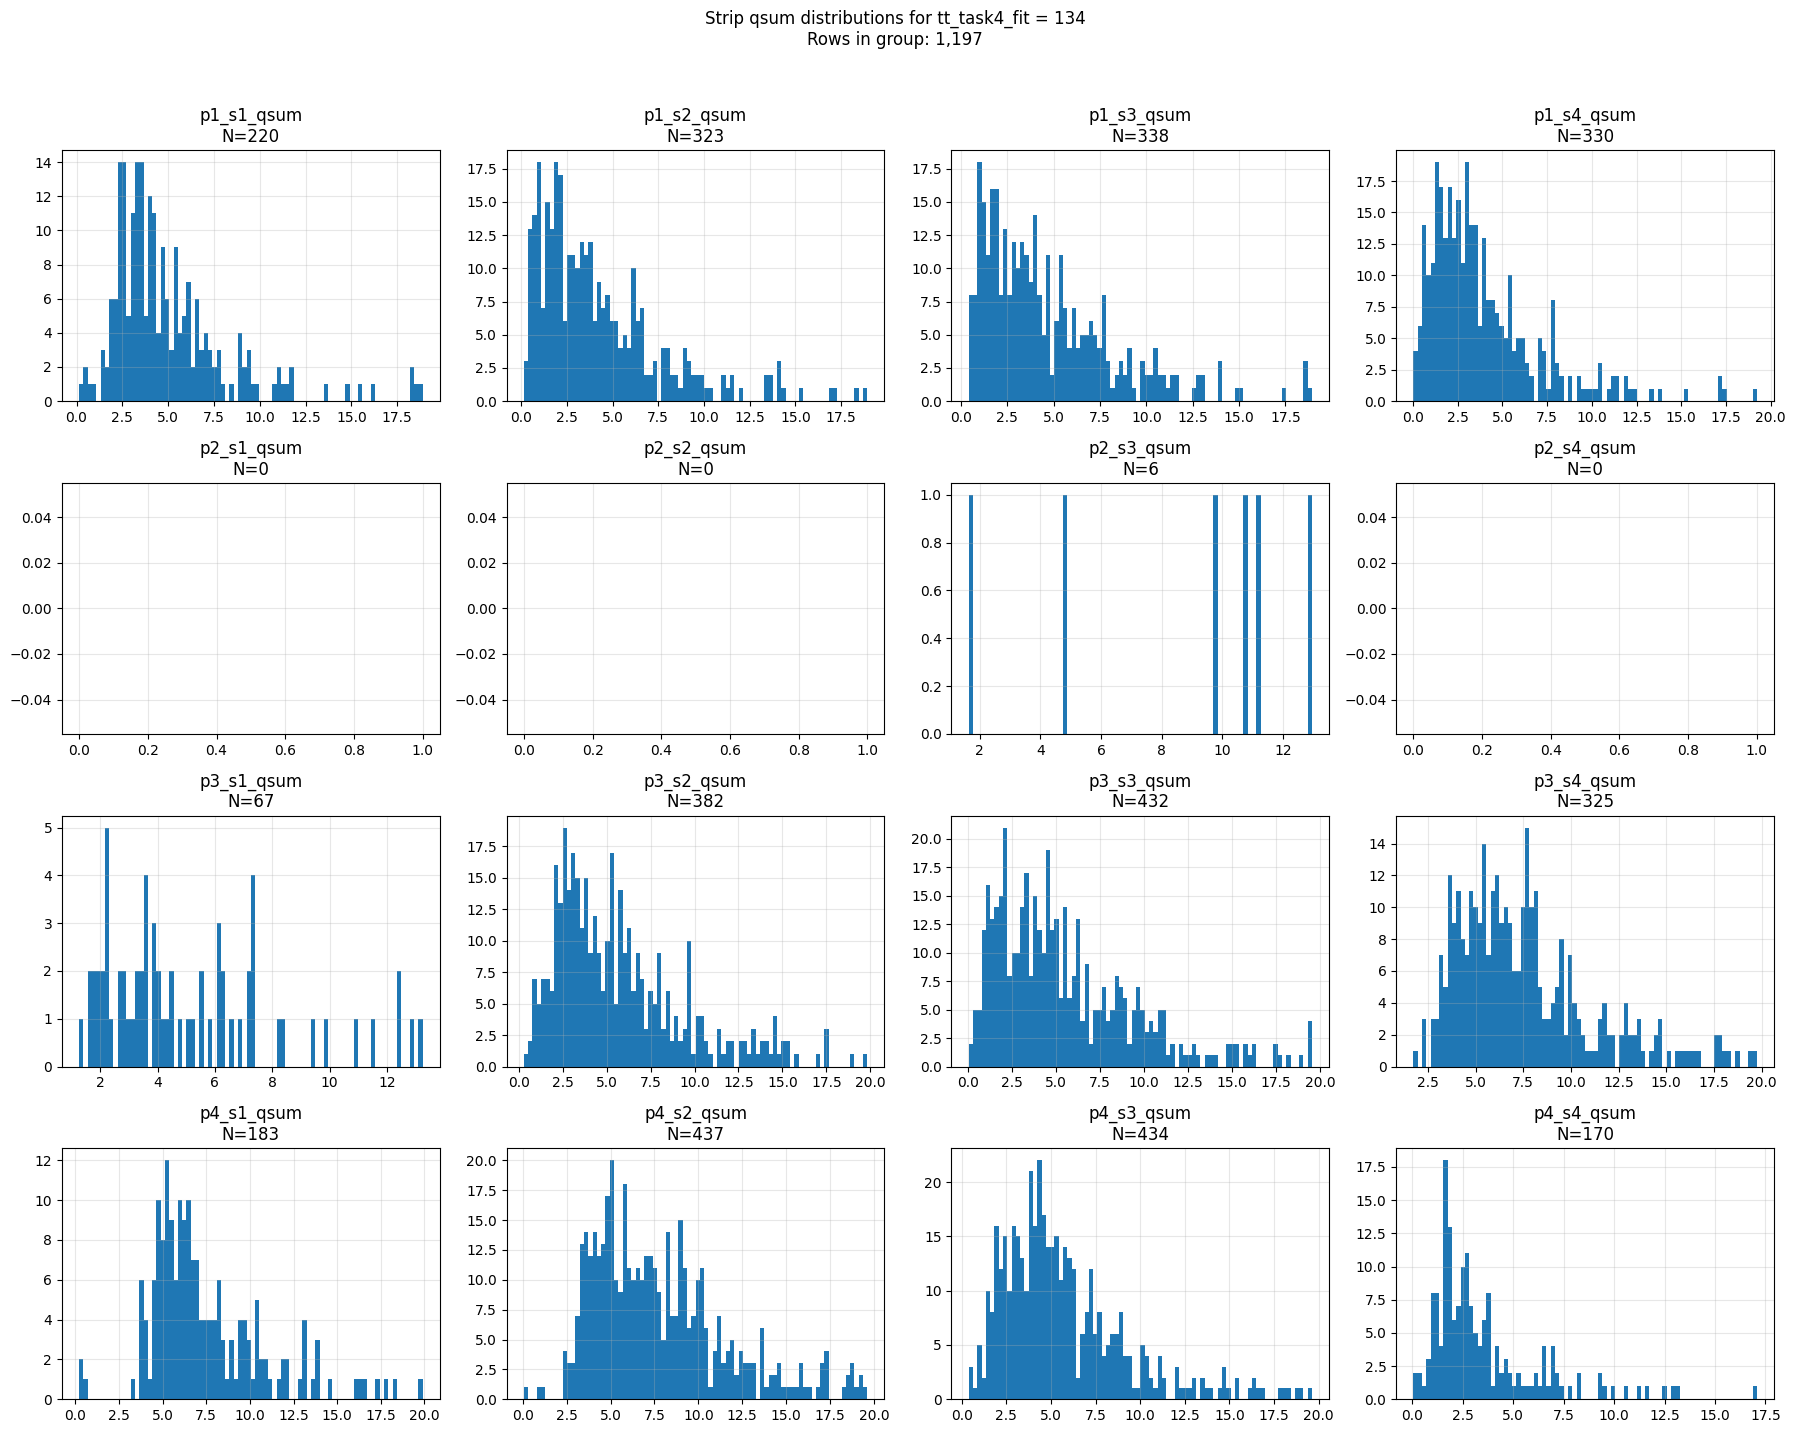

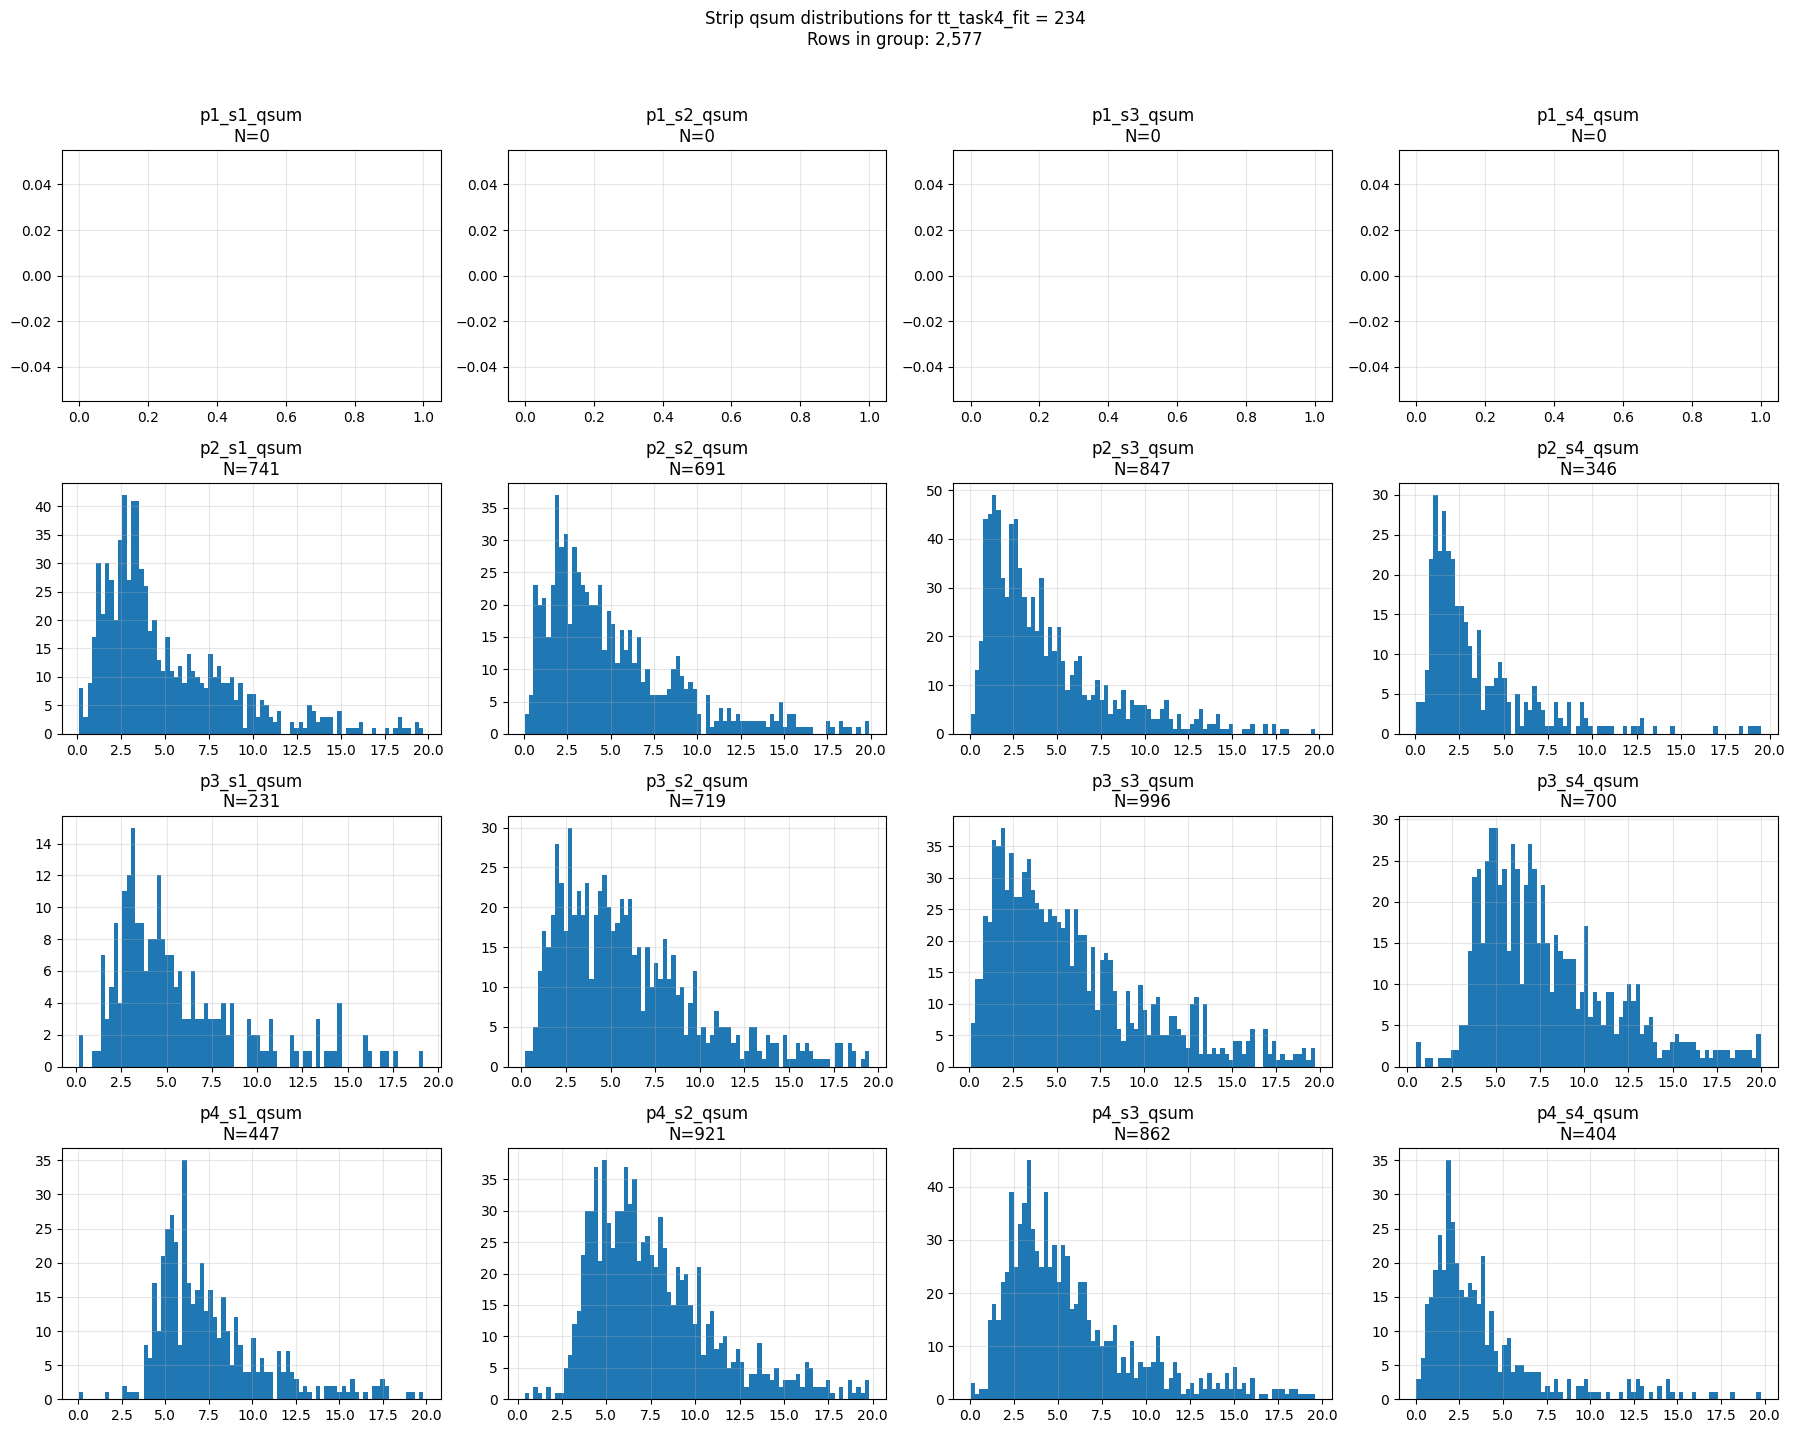

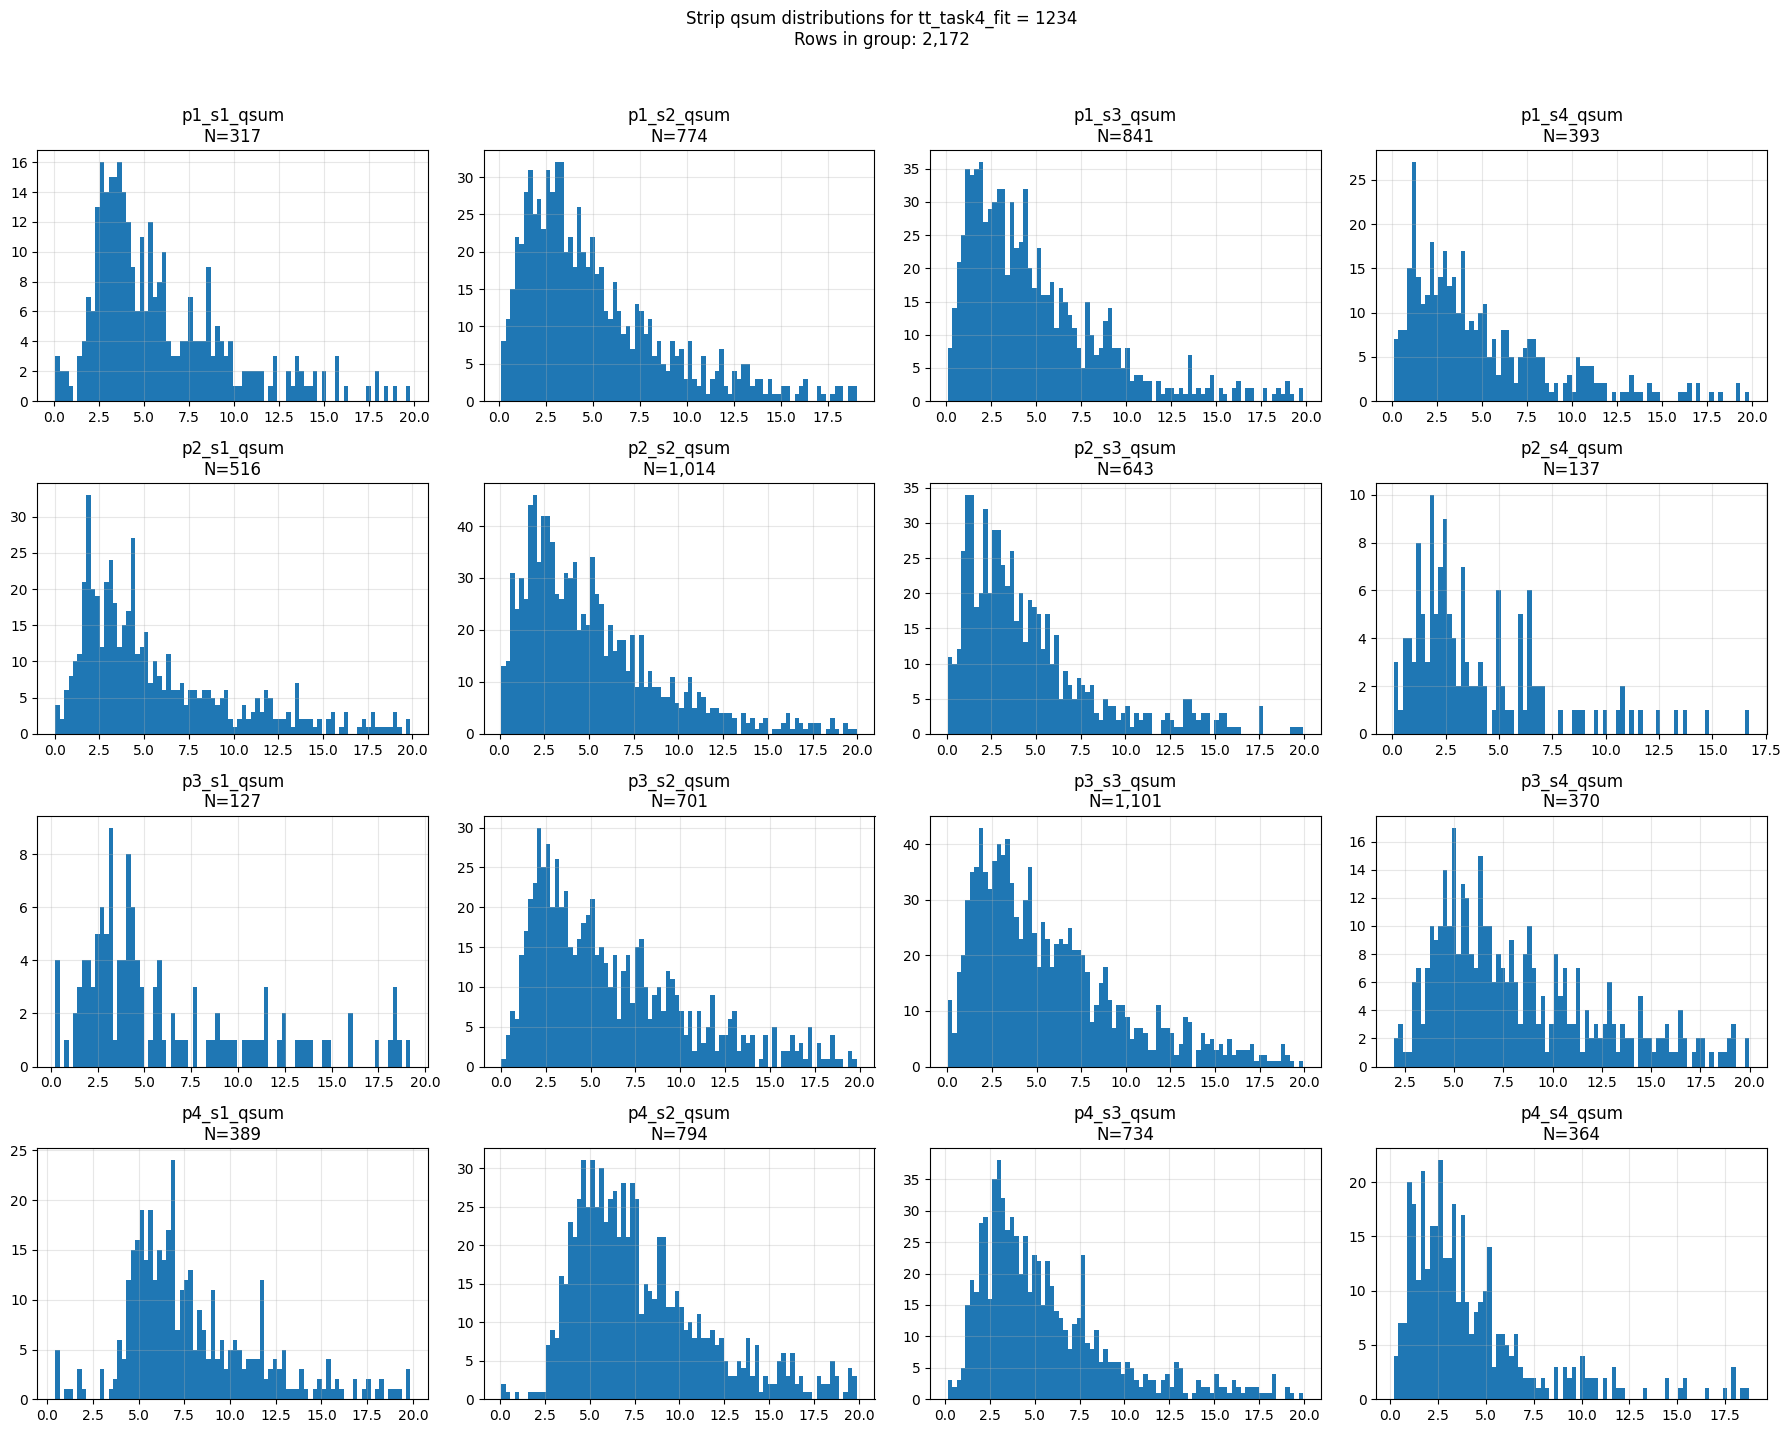

In [18]:
def plot_strip_quantity_grid_by_tt_task4_fit(
    quantity: str,
    bins=80,
    time_col: str = "tt_task4_fit",
    q_min: float = 0,
    q_max: float = 20,
):
    if time_col not in df.columns:
        print(f"Missing time/grouping column: {time_col}")
        return

    cols = []
    for plane in range(1, 5):
        for strip in range(1, 5):
            col = f"p{plane}_s{strip}_{quantity}"
            if col in df.columns:
                cols.append((plane, strip, col))

    if not cols:
        print(f"No strip columns found for quantity: {quantity}")
        return

    time_values = (
        df[time_col]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    if not time_values:
        print(f"No valid values found in {time_col}")
        return

    print(f"Found {len(time_values)} unique values in {time_col}")

    for tt_value in time_values:
        sub_df = df[df[time_col] == tt_value]

        if sub_df.empty:
            continue

        fig, axes = plt.subplots(4, 4, figsize=(18, 14), squeeze=False)

        for plane, strip, col in cols:
            ax = axes[plane - 1][strip - 1]

            values = (
                pd.to_numeric(sub_df[col], errors="coerce")
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
            )

            values = values[(values > q_min) & (values < q_max)]

            if len(values) > MAX_ROWS_FOR_PLOTS:
                values = values.sample(MAX_ROWS_FOR_PLOTS, random_state=RANDOM_SEED)

            ax.hist(values, bins=bins)
            ax.set_title(f"{col}\nN={len(values):,}")
            ax.grid(True, alpha=0.3)

        for ax in axes.ravel():
            if not ax.get_title():
                ax.axis("off")

        fig.suptitle(
            f"Strip {quantity} distributions for {time_col} = {tt_value}\n"
            f"Rows in group: {len(sub_df):,}",
            y=1.02,
        )
        fig.tight_layout()
        plt.show()


plot_strip_quantity_grid_by_tt_task4_fit("qsum")

Overlaying 11 unique values from tt_task4_fit
time_values: [12, 13, 14, 23, 24, 34, 123, 124, 134, 234, 1234]


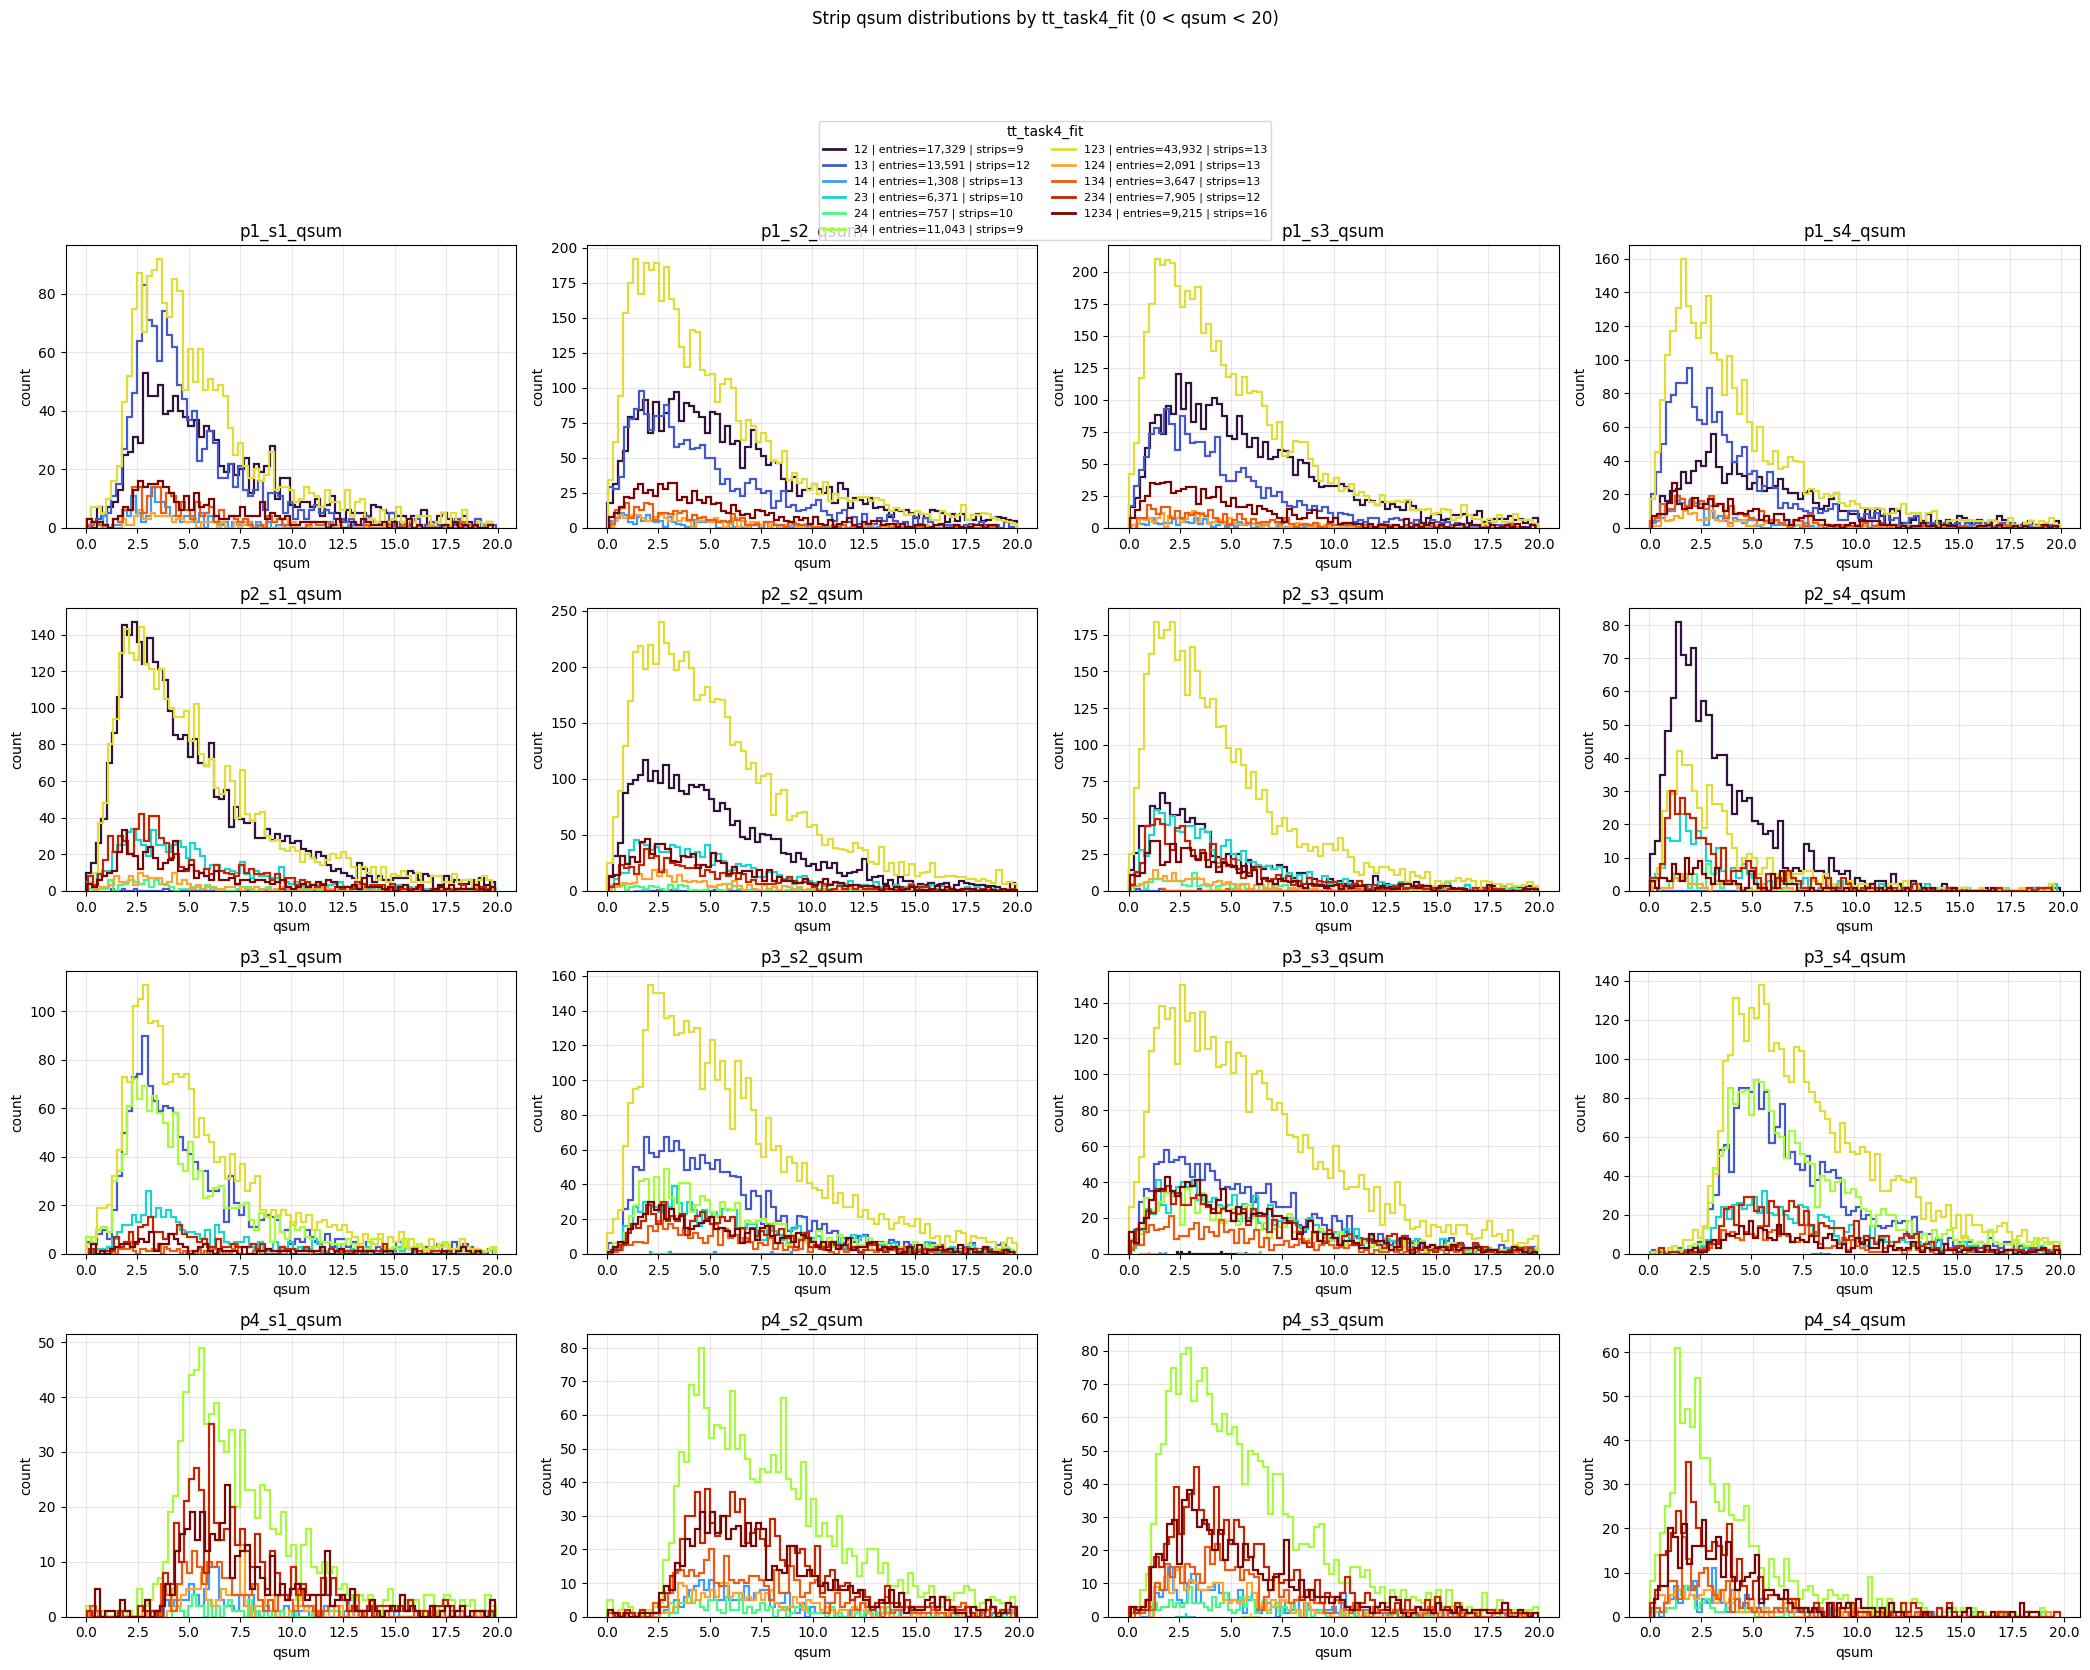

Visible entries after cuts:
  tt_task4_fit=12: entries=17,329, visible_strips=9
  tt_task4_fit=13: entries=13,591, visible_strips=12
  tt_task4_fit=14: entries=1,308, visible_strips=13
  tt_task4_fit=23: entries=6,371, visible_strips=10
  tt_task4_fit=24: entries=757, visible_strips=10
  tt_task4_fit=34: entries=11,043, visible_strips=9
  tt_task4_fit=123: entries=43,932, visible_strips=13
  tt_task4_fit=124: entries=2,091, visible_strips=13
  tt_task4_fit=134: entries=3,647, visible_strips=13
  tt_task4_fit=234: entries=7,905, visible_strips=12
  tt_task4_fit=1234: entries=9,215, visible_strips=16


In [23]:
from matplotlib.lines import Line2D

def plot_strip_quantity_grid_histstep_by_tt_task4_fit(
    quantity: str,
    bins=80,
    time_col: str = "tt_task4_fit",
    q_min: float = 0,
    q_max: float = 20,
    max_time_values: int | None = None,
    density: bool = False,
    linewidth: float = 1.6,
):
    if time_col not in df.columns:
        print(f"Missing time/grouping column: {time_col}")
        return

    cols = []
    for plane in range(1, 5):
        for strip in range(1, 5):
            col = f"p{plane}_s{strip}_{quantity}"
            if col in df.columns:
                cols.append((plane, strip, col))

    if not cols:
        print(f"No strip columns found for quantity: {quantity}")
        return

    # Work with a numeric copy of the grouping column to avoid dtype-comparison problems.
    work_df = df.copy()
    work_df["_tt_group_numeric"] = (
        pd.to_numeric(work_df[time_col], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
    )

    time_values = (
        work_df["_tt_group_numeric"]
        .dropna()
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    if max_time_values is not None:
        time_values = time_values[:max_time_values]

    if not time_values:
        print(f"No valid values found in {time_col}")
        return

    print(f"Overlaying {len(time_values)} unique values from {time_col}")
    print("time_values:", time_values)

    # Use a global color mapping, independent of subplot visibility.
    cmap = plt.get_cmap("turbo", len(time_values))
    color_by_tt = {
        tt_value: cmap(idx)
        for idx, tt_value in enumerate(time_values)
    }

    visibility = {tt_value: 0 for tt_value in time_values}
    visible_strips = {tt_value: 0 for tt_value in time_values}

    fig, axes = plt.subplots(4, 4, figsize=(21, 15), squeeze=False)

    for plane, strip, col in cols:
        ax = axes[plane - 1][strip - 1]

        for tt_value in time_values:
            sub_df = work_df[work_df["_tt_group_numeric"] == tt_value]

            values = (
                pd.to_numeric(sub_df[col], errors="coerce")
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
            )

            values = values[(values > q_min) & (values < q_max)]

            if values.empty:
                continue

            visibility[tt_value] += len(values)
            visible_strips[tt_value] += 1

            if len(values) > MAX_ROWS_FOR_PLOTS:
                values = values.sample(MAX_ROWS_FOR_PLOTS, random_state=RANDOM_SEED)

            ax.hist(
                values,
                bins=bins,
                histtype="step",
                density=density,
                linewidth=linewidth,
                color=color_by_tt[tt_value],
            )

        ax.set_title(col)
        ax.set_xlabel(quantity)
        ax.set_ylabel("density" if density else "count")
        ax.grid(True, alpha=0.3)

    for ax in axes.ravel():
        if not ax.get_title():
            ax.axis("off")

    # Build legend globally, not from axes[0][0].
    legend_handles = [
        Line2D(
            [0],
            [0],
            color=color_by_tt[tt_value],
            lw=2.0,
            label=(
                f"{tt_value:g} | entries={visibility[tt_value]:,} "
                f"| strips={visible_strips[tt_value]}"
            ),
        )
        for tt_value in time_values
    ]

    fig.legend(
        handles=legend_handles,
        title=time_col,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.04),
        ncol=2,
        fontsize=8,
    )

    fig.suptitle(
        f"Strip {quantity} distributions by {time_col} "
        f"({q_min} < {quantity} < {q_max})",
        y=1.11,
    )

    fig.tight_layout()
    plt.show()

    print("Visible entries after cuts:")
    for tt_value in time_values:
        print(
            f"  {time_col}={tt_value:g}: "
            f"entries={visibility[tt_value]:,}, "
            f"visible_strips={visible_strips[tt_value]}"
        )


plot_strip_quantity_grid_histstep_by_tt_task4_fit("qsum", density=False)

## 11. Manual save example


In [ ]:
# Example:
#
# local = clean_xy("event_x", "event_y", max_rows=MAX_ROWS_FOR_SCATTER)
# plt.figure(figsize=(7, 6))
# plt.scatter(local["event_x"], local["event_y"], s=4, alpha=0.25)
# plt.xlabel("event_x")
# plt.ylabel("event_y")
# plt.title("event_y vs event_x")
# plt.grid(True, alpha=0.3)
# plt.savefig("event_y_vs_event_x.png", dpi=150, bbox_inches="tight")
# plt.show()
